# Figure 1, Figure 6 & fig. S1 — salivary-gland single-cell / TCR analysis

**Takeshita M, Inamo J, et al. _Identification of a shared antigen linking CD4⁺ T and B cell pathology in Sjögren's disease._ Sci. Adv. (2026).**

Reproduces the manuscript's computational figures: **Fig. 1** (broad cell types, T-cell subclusters, markers), **fig. S1** (T-cell marker heatmap and per-sample distribution), and **Fig. 6A** (TCR-tested and Ro60-reactive clonotypes on the T-cell UMAP). Saved Harmony embeddings are reused so the UMAPs match the paper. Figures render inline; no files are written.

The salivary-gland vs peripheral-blood comparison (fig. S6) is in **`03_tcr_repertoire.ipynb`**.

In [1]:
# ==============================================================================
# 02_figure_analysis  -  Figure 1 and downstream TCR-repertoire analysis
# Reproduces the manuscript figures (Takeshita, Inamo et al., Sci. Adv. 2026)
# ==============================================================================
source("utils.R")
dir <- paste0(getwd(), "/../")
data_type <- "GEX"

Warning message:
“package ‘Seurat’ was built under R version 4.3.3”
Warning message:
“package ‘SeuratObject’ was built under R version 4.3.3”
Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”
Warning message:
“package ‘ggpubr’ was built under R version 4.3.3”


In [2]:
# Figure files written by this notebook go to a dedicated folder so that the
# original published outputs are never overwritten. Plots are also shown inline.
fig_dir <- file.path(getwd(), "ipynb_figures")
dir.create(fig_dir, showWarnings = FALSE)

In [3]:
options(repr.plot.width = 7, repr.plot.height = 6)
# ------------------------------------------------------------------------------
# Inline figure display.
# Every figure is rendered inline in this notebook. We shadow the file-writing
# graphics calls so that ggsave()/pdf()/png() display the plot instead of
# writing a file: this guarantees the figures are embedded in the notebook and
# never overwrites any existing result file.
# ------------------------------------------------------------------------------
options(repr.plot.width = 7, repr.plot.height = 6)
# Figures render inline; ggsave/pdf/png are shadowed so they DISPLAY the plot
# instead of writing a file. The intended width/height is applied per cell by
# the notebook (an options(repr.plot.*) line is prepended to each plotting cell),
# so no result files are written and existing outputs are never overwritten.
ggsave  <- function(filename = NULL, plot = ggplot2::last_plot(), ...) { print(plot); invisible(plot) }
pdf     <- function(...) invisible(NULL)
png     <- function(...) invisible(NULL)
dev.off <- function(...) invisible(NULL)

In [4]:
# ------------------------------------------------------------------------------
# Load the all-cell object and reproduce the published Figure 1A embedding.
#
# The merged object stores the Harmony embedding that was used for the paper.
# Figure 1A was built from Harmony dims 1:8 at clustering resolution 0.1.
# Re-running PCA/Harmony from scratch drifts between software versions, so we
# keep the stored Harmony embedding FIXED and only recompute the neighbour
# graph, clusters and UMAP. This reproduces the manuscript UMAP exactly.
# ------------------------------------------------------------------------------
gex <- readRDS(paste0(dir, "/output/SeuratObj_merged_", data_type, ".rds"))
gex <- JoinLayers(gex)
all.genes <- rownames(gex)
set.seed(1234)
gex <- FindNeighbors(gex, reduction = "harmony", dims = 1:8, k.param = 30, verbose = FALSE)
gex <- FindClusters(gex, resolution = 0.1, verbose = FALSE)
gex <- RunUMAP(gex, reduction = "harmony", dims = 1:8, n.neighbors = 30L, min.dist = 0.3, verbose = FALSE)
# Standardise embedding column names used throughout the script.
colnames(gex@reductions$umap@cell.embeddings) <- c("umap_1", "umap_2")
gex@reductions$umap@key <- "umap_"

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by ‘BiocGenerics’

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by ‘BiocGenerics’



In [5]:
# ------------------------------------------------------------------------------
# Cluster -> broad cell type, matching the manuscript Figure 1A annotation:
#   0 T cell | 1 Plasma cell | 2 Aciner | 3 B cell | 4 Duct & Stem |
#   5 Aciner | 6 Myeloid | 7 Fibroblast & Stem | 8 Plasma cell | 9 Plasmablast
# ------------------------------------------------------------------------------
celltype_levels <- c("0" = "T cell", "1" = "Plasma cell", "2" = "Aciner",
                     "3" = "B cell", "4" = "Duct & Stem", "5" = "Aciner",
                     "6" = "Myeloid", "7" = "Fibroblast & Stem",
                     "8" = "Plasma cell", "9" = "Plasmablast")
gex$new_cluster <- unname(celltype_levels[as.character(gex$seurat_clusters)])
cluster_labels  <- paste0("Cluster-", names(celltype_levels), ": ", celltype_levels)
celltype_colors <- c("T cell" = "#E41A1C", "Plasma cell" = "#377EB8",
                     "Aciner" = "#4DAF4A", "B cell" = "#984EA3",
                     "Duct & Stem" = "#FF7F00", "Myeloid" = "#A65628",
                     "Fibroblast & Stem" = "lightgrey", "Plasmablast" = "#66C2A5")

## Figure 1A–B — Broad cell types in the salivary gland

The all-cell object is loaded and its stored Harmony embedding reused; only the neighbour graph, clustering (resolution 0.1) and UMAP (Harmony dims 1:8) are recomputed, reproducing Figure 1A. Clusters 0–9 are annotated as 0 T cell, 1 Plasma cell, 2 Aciner, 3 B cell, 4 Duct & Stem, 5 Aciner, 6 Myeloid, 7 Fibroblast & Stem, 8 Plasma cell, 9 Plasmablast. Panel **B** is the marker-gene dot plot.

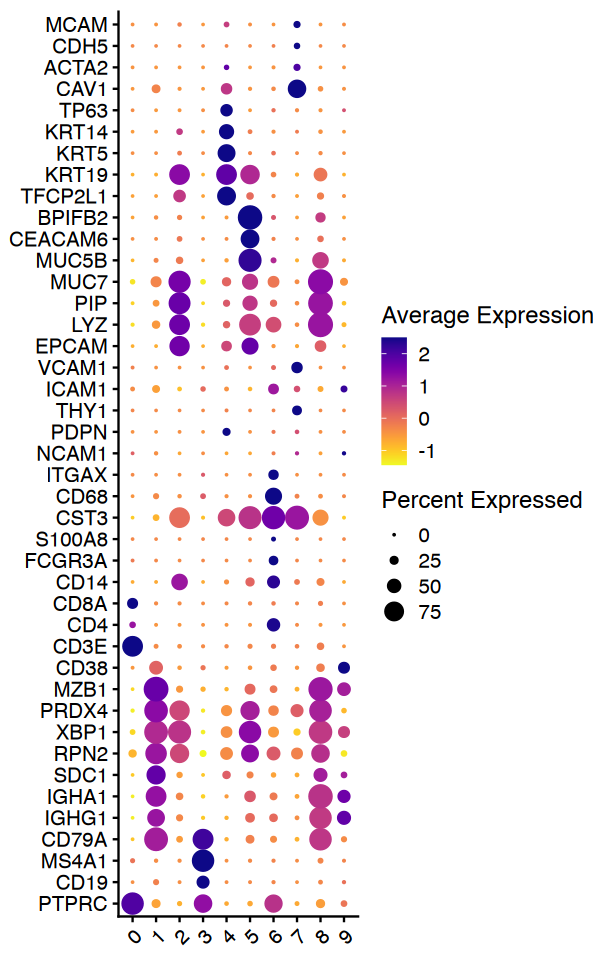

In [6]:
options(repr.plot.width = 5, repr.plot.height = 8)
g = DotPlot_scCustom(gex, features = all_markers, flip_axes = T, x_lab_rotate = TRUE)
ggsave(paste0(fig_dir,"/Dotplot.pdf"), 
       plot = g, 
       width = 5, height = 8)

In [7]:
print(table(Idents(gex)))


    0     1     2     3     4     5     6     7     8     9 
10364  6135  5656  2098  2073  2058   870   801   611   552 


In [8]:
min_cell_cluster = 200
# min_cell_cluster = sum(table(Idents(gex))) * 0.005

In [9]:
print(table(Idents(gex)))
print(names(table(Idents(gex))))
print(table(Idents(gex))>min_cell_cluster)
print(names(table(Idents(gex)))[table(Idents(gex))>min_cell_cluster])


    0     1     2     3     4     5     6     7     8     9 
10364  6135  5656  2098  2073  2058   870   801   611   552 
 [1] "0" "1" "2" "3" "4" "5" "6" "7" "8" "9"

   0    1    2    3    4    5    6    7    8    9 
TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE 
 [1] "0" "1" "2" "3" "4" "5" "6" "7" "8" "9"


In [10]:
gex = subset(gex, 
             idents = names(table(Idents(gex)))[table(Idents(gex))>min_cell_cluster])

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.”


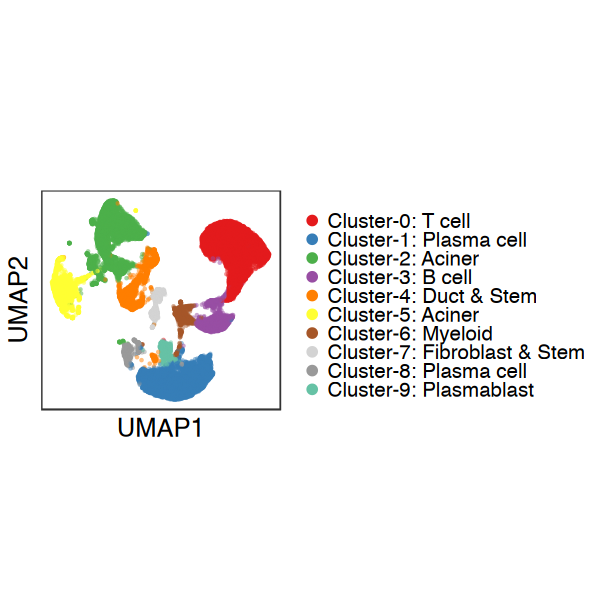

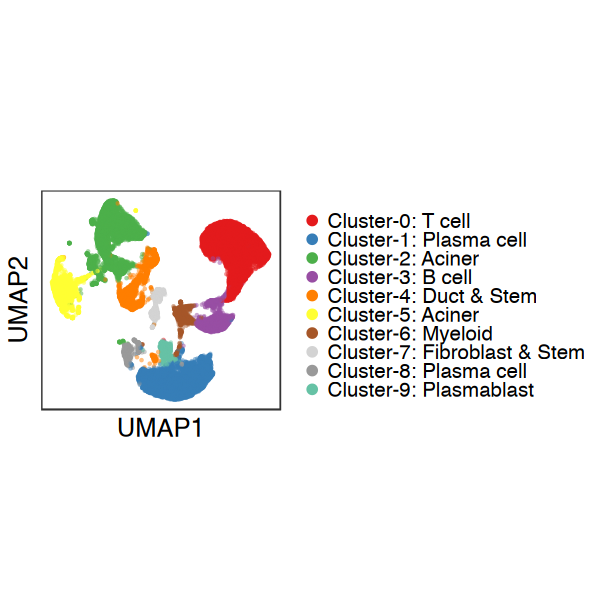

In [11]:
options(repr.plot.width = 5, repr.plot.height = 5)
g = ggplot() +
       geom_point(
         data = data.frame(gex[["umap"]]@cell.embeddings,
                           res_cell = Idents(gex)) %>%
           dplyr::sample_frac(1L),
         mapping = aes_string(x = "umap_1", y = "umap_2", color = "res_cell"),
         size = 1, stroke = 0, shape = 16, alpha = 0.5
       ) +
       scale_color_manual(values=manual_colors, labels=cluster_labels) +
       scale_fill_manual(values=manual_colors) +
       labs(
         x = "UMAP1",
         y = "UMAP2",
         title = ""
       ) +
       coord_fixed() +
       theme_bw(base_size = 10) +
       theme(
         legend.position = "right",
         axis.ticks = element_blank(),
         panel.grid = element_blank(),
         plot.title = element_text(size=15),
         axis.title.x = element_text(size=15),
         axis.title.y = element_text(size =15),
         axis.text.y = element_blank(),
         axis.text.x = element_blank(),
         legend.text =  element_text(size = 12),
         legend.key.size = grid::unit(0.5, "lines"),
         legend.title = element_text(size = 0.8, hjust = 0)
       ) + guides(colour = guide_legend(override.aes = list(size=3,alpha=1),
                                        title = "",
                                        ncol = 1),
                  fill="none")
g
ggsave(paste0(fig_dir,"/UMAP.pdf"), 
       plot = g, 
       width = 5, height = 5)

In [12]:
# Find cluster center
cluster_center <- data.frame(gex[["umap"]]@cell.embeddings,
                             res_cell = Idents(gex)) %>%
  dplyr::group_by(res_cell) %>%
  dplyr::summarise_at(vars(umap_1, umap_2), dplyr::funs(median(., na.rm=TRUE)))
cluster_center <- as.data.frame(cluster_center)
cluster_center$res_cell <- as.character(cluster_center$res_cell)

Warning message:
“`funs()` was deprecated in dplyr 0.8.0.
ℹ Please use a list of either functions or lambdas:

# Simple named list: list(mean = mean, median = median)

# Auto named with `tibble::lst()`: tibble::lst(mean, median)

# Using lambdas list(~ mean(., trim = .2), ~ median(., na.rm = TRUE))”


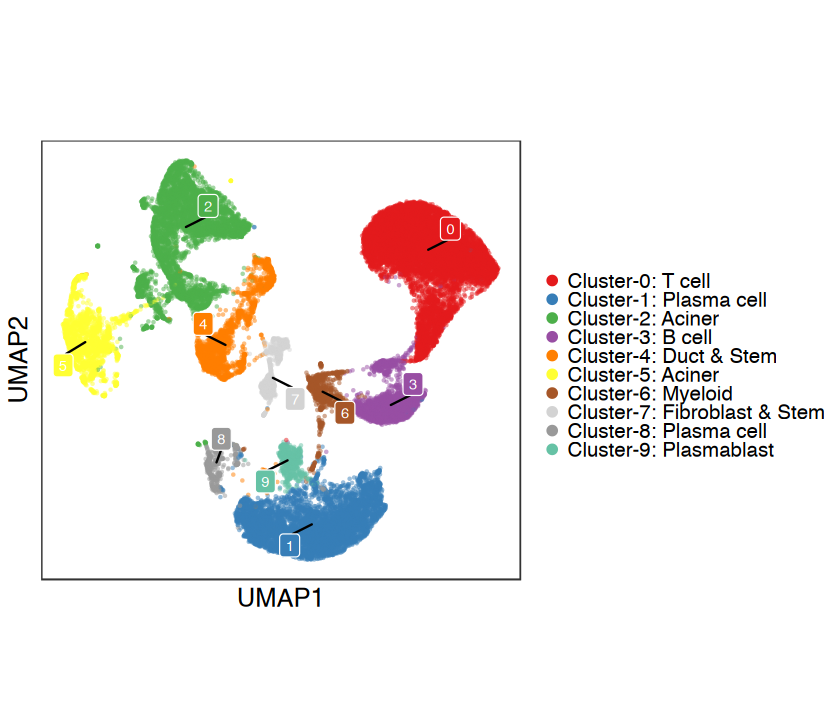

In [13]:
options(repr.plot.width = 7, repr.plot.height = 6)
plot(ggplot() +
       geom_point(
         data = data.frame(gex[["umap"]]@cell.embeddings,
                           res_cell = Idents(gex)) %>%
           dplyr::sample_frac(1L),
         mapping = aes_string(x = "umap_1", y = "umap_2", color = "res_cell"),
         size = 1, stroke = 0, shape = 16, alpha = 0.5
       ) +
       ggrepel::geom_label_repel(
         data = cluster_center,
         aes(x = umap_1, y = umap_2, label = res_cell, fill = res_cell),
         color = "white",segment.color = "black",
         size = 3,
         min.segment.length = 0, seed = 42, box.padding = 0.5
       ) +
       scale_color_manual(labels = cluster_labels,
                          values=manual_colors) +
       scale_fill_manual(values=manual_colors) +
       labs(
         x = "UMAP1",
         y = "UMAP2",
         title = ""
       ) +
       coord_fixed() +
       theme_bw(base_size = 10) +
       theme(
         legend.position = "right",
         axis.ticks = element_blank(),
         panel.grid = element_blank(),
         plot.title = element_text(size=15),
         axis.title.x = element_text(size=15),
         axis.title.y = element_text(size =15),
         axis.text.y = element_blank(),
         axis.text.x = element_blank(),
         legend.text =  element_text(size = 12),
         legend.key.size = grid::unit(0.5, "lines"),
         legend.title = element_text(size = 0.8, hjust = 0)
       ) + guides(colour = guide_legend(override.aes = list(size=3,alpha=1),
                                        title = "",
                                        ncol = 1),
                  fill="none")
)

In [14]:
gex <- JoinLayers(gex, overwrite = TRUE)

### Cell-type annotated UMAP (Figure 1A)

In [15]:
gex@meta.data$new_cluster = dplyr::case_when(
  gex@meta.data$seurat_clusters %in% c("0") ~ "T cell",
  gex@meta.data$seurat_clusters %in% c("1","8") ~ "Plasma cell",
  gex@meta.data$seurat_clusters %in% c("2","5") ~ "Aciner",
  gex@meta.data$seurat_clusters %in% c("3") ~ "B cell",
  gex@meta.data$seurat_clusters %in% c("4") ~ "Duct & Stem",
  gex@meta.data$seurat_clusters %in% c("6") ~ "Myeloid",
  gex@meta.data$seurat_clusters %in% c("7") ~ "Fibroblast & Stem",
  gex@meta.data$seurat_clusters %in% c("9") ~ "Plasmablast"
)

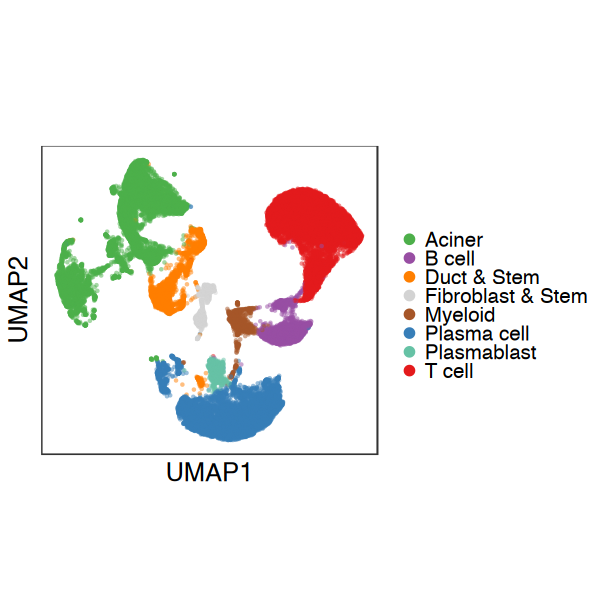

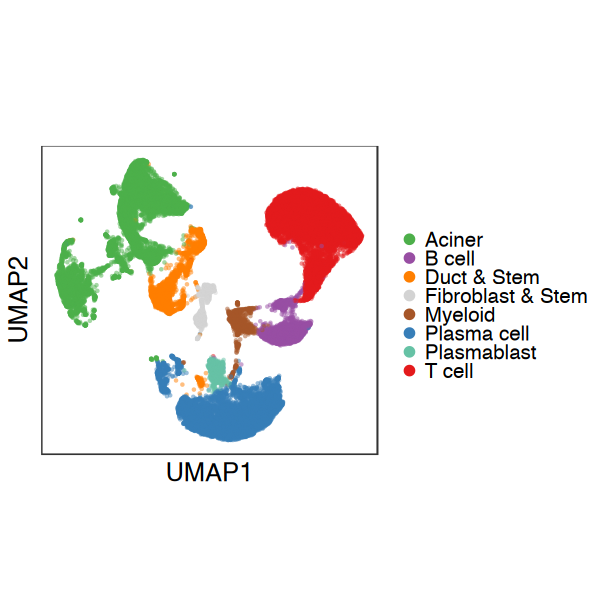

In [16]:
options(repr.plot.width = 5, repr.plot.height = 5)
g = ggplot() +
  geom_point(
    data = data.frame(gex[["umap"]]@cell.embeddings,
                      res_cell = gex@meta.data$new_cluster) %>%
      dplyr::sample_frac(1L),
    mapping = aes_string(x = "umap_1", y = "umap_2", color = "res_cell"),
    size = 1, stroke = 0, shape = 16, alpha = 0.5
  ) +
  scale_color_manual(values = celltype_colors) +
  labs(
    x = "UMAP1",
    y = "UMAP2",
    title = ""
  ) +
  coord_fixed() +
  theme_bw(base_size = 10) +
  theme(
    legend.position = "right",
    axis.ticks = element_blank(),
    panel.grid = element_blank(),
    plot.title = element_text(size=15),
    axis.title.x = element_text(size=15),
    axis.title.y = element_text(size =15),
    axis.text.y = element_blank(),
    axis.text.x = element_blank(),
    legend.text =  element_text(size = 12),
    legend.key.size = grid::unit(0.5, "lines"),
    legend.title = element_text(size = 0.8, hjust = 0)
  ) + guides(colour = guide_legend(override.aes = list(size=3,alpha=1),
                                   title = "",
                                   ncol = 1),
             fill="none")
g
ggsave(paste0(fig_dir,"/UMAP_celltype.pdf"), 
       plot = g, 
       width = 5, height = 5)

## Figure 1C–D & fig. S1 — T-cell subclusters

T-lineage cells are selected and the published T-cell object (Harmony dims 1:20, resolution 1.0, 10 sub-clusters) is loaded so the UMAP/clusters match the paper. Includes the per-sample density UMAP and marker heatmap (fig. S1).

In [17]:
gex_t = subset(gex, 
               # idents = "1", 
               subset = CD19 < 0.5 & MS4A1 < 0.5 & CD79A < 0.5 & MZB1 < 0.5 & IGHG1 < 0.5 & IGHA1 < 0.5 & IGHD < 0.5 & CD3E > 1 & CD14 < 0.5 & CD68 < 0.5 & TYROBP < 0.5 & NCAM1 < 0.5 & MUC7 < 0.5 & MUC5B < 0.5 & KRT19 < 0.5 & KRT5 < 0.5 & KRT14 < 0.5)
print(gex_t)
print(table(gex_t@meta.data$seurat_clusters))
prop = paste0(round(100*table(gex_t@meta.data$seurat_clusters)/table(gex@meta.data$seurat_clusters), digits = 2),"%")
names(prop) = names(table(gex@meta.data$seurat_clusters))
print(prop)
print(table(gex_t@meta.data$orig.ident))

An object of class Seurat 
36601 features across 6891 samples within 1 assay 
Active assay: RNA (36601 features, 2000 variable features)
 3 layers present: data, counts, scale.data
 3 dimensional reductions calculated: pca, harmony, umap

   0    1    2    3    4    5    6    7    8    9 
6860    0    0    8    2    0    2   19    0    0 
       0        1        2        3        4        5        6        7 
"66.19%"     "0%"     "0%"  "0.38%"   "0.1%"     "0%"  "0.23%"  "2.37%" 
       8        9 
    "0%"     "0%" 

GEX_LB183 GEX_LB189 GEX_LB214 GEX_LB215 GEX_LB216 GEX_LB219 GEX_LB220 GEX_LB221 
      452       718       413       671       800      2443      1158       236 


In [18]:
# include cells with TCR
gex_t = subset(gex_t, cells = cellranger_rep[cellranger_rep$cell_type=="T",]$sample_barcode)
print(gex_t)

An object of class Seurat 
36601 features across 6217 samples within 1 assay 
Active assay: RNA (36601 features, 2000 variable features)
 3 layers present: data, counts, scale.data
 3 dimensional reductions calculated: pca, harmony, umap


In [19]:
print(table(gex_t@meta.data$seurat_clusters))
prop = paste0(round(100*table(gex_t@meta.data$seurat_clusters)/table(gex@meta.data$seurat_clusters), digits = 2),"%")
names(prop) = names(table(gex@meta.data$seurat_clusters))
print(prop)
print(table(gex_t@meta.data$orig.ident))


   0    1    2    3    4    5    6    7    8    9 
6189    0    0    7    2    0    0   19    0    0 
       0        1        2        3        4        5        6        7 
"59.72%"     "0%"     "0%"  "0.33%"   "0.1%"     "0%"     "0%"  "2.37%" 
       8        9 
    "0%"     "0%" 

GEX_LB183 GEX_LB189 GEX_LB214 GEX_LB215 GEX_LB216 GEX_LB219 GEX_LB220 GEX_LB221 
      353       654       342       607       754      2280      1019       208 


In [20]:
tmp = gex_t@meta.data %>%
  dplyr::group_by(orig.ident) %>%
  dplyr::summarise(cell_counts = n()) %>%
  dplyr::summarise(Total_cell_count=sum(cell_counts), ind_variance=var(cell_counts))

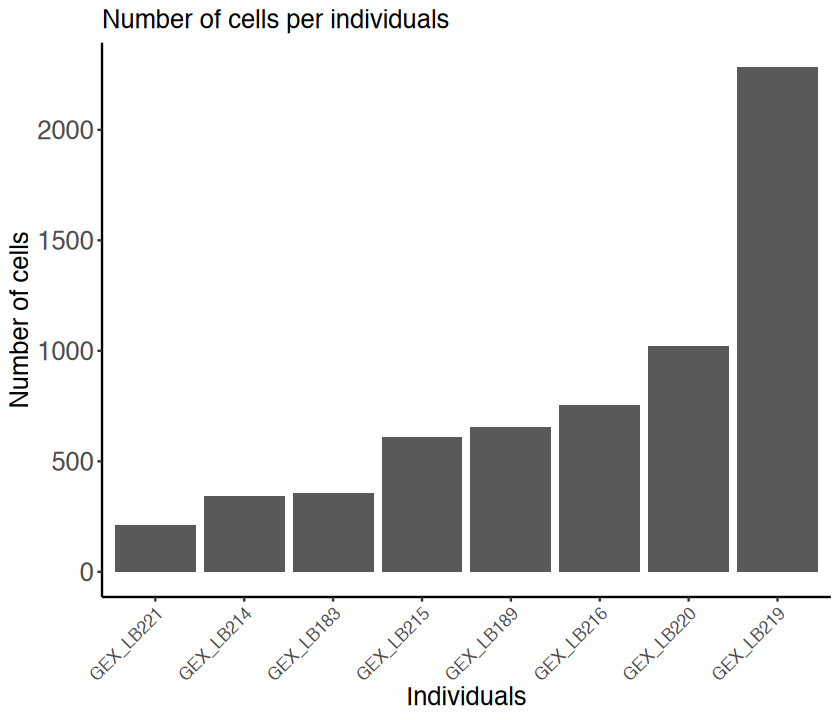

In [21]:
options(repr.plot.width = 7, repr.plot.height = 6)
plot(
  gex_t@meta.data %>%
    dplyr::group_by(orig.ident) %>%
    dplyr::summarise(cell_counts = n()) %>%
    dplyr::ungroup() %>%
    dplyr::arrange(desc(cell_counts)) %>%
    ggplot() + 
    geom_bar(aes(reorder(orig.ident,cell_counts),cell_counts), stat = 'identity') + 
    theme_classic() +
    theme(strip.text.x=element_text(size=15, color="black", face="bold"),
          strip.text.y=element_text(size=15, color="black", face="bold"),
          legend.position = "bottom",
          plot.title = element_text(size=15),
          axis.title.x = element_text(size=15),
          axis.title.y = element_text(size =15),
          axis.text.y = element_text(size = 15),
          axis.text.x = element_text(size = 10, angle = 45, hjust = 1),
          legend.text =  element_text(size = 10), 
          legend.key.size = grid::unit(0.8, "lines"),
          legend.title = element_text(size = 0, hjust = 0)) +
    labs(title = paste0("Number of cells per individuals"),
         x = 'Individuals',
         y = "Number of cells") 
)

In [22]:
# --- Load the published T-cell object (Figure 1C/D) ---------------------------
# The T-cell sub-embedding (Harmony dims 1:20, resolution 1.0) is loaded from
# the saved object so that the UMAP and the 10 sub-clusters match the paper.
gex_t <- readRDS(paste0(dir, "/output/SeuratObj_T_merged_GEX.rds"))
gex_t <- JoinLayers(gex_t)
Idents(gex_t) <- gex_t$seurat_clusters
colnames(gex_t@reductions$umap@cell.embeddings) <- c("umap_1", "umap_2")
gex_t@reductions$umap@key <- "umap_"
all.genes <- rownames(gex_t)
min_cell_cluster = 50
gex_t = subset(gex_t,
               idents = names(table(Idents(gex_t)))[table(Idents(gex_t)) > min_cell_cluster])

In [23]:
cluster_center <- data.frame(gex_t[["umap"]]@cell.embeddings,
                             res_cell = Idents(gex_t)) %>%
  dplyr::group_by(res_cell) %>%
  dplyr::summarise_at(vars(umap_1, umap_2), dplyr::funs(median(., na.rm=TRUE)))
cluster_center <- as.data.frame(cluster_center)
cluster_center$res_cell <- as.character(cluster_center$res_cell)

Warning message:
“`funs()` was deprecated in dplyr 0.8.0.
ℹ Please use a list of either functions or lambdas:

# Simple named list: list(mean = mean, median = median)

# Auto named with `tibble::lst()`: tibble::lst(mean, median)

# Using lambdas list(~ mean(., trim = .2), ~ median(., na.rm = TRUE))”


In [24]:
options(repr.plot.width = 7, repr.plot.height = 6)
g = ggplot() +
       geom_point(
         data = data.frame(gex_t[["umap"]]@cell.embeddings,
                           res_cell = Idents(gex_t)),
         mapping = aes_string(x = "umap_1", y = "umap_2", color = "res_cell"),
         size = 2, stroke = 0, shape = 16, alpha = 0.5
       ) +
       # ggrepel::geom_label_repel(
  #   data = cluster_center,
  #   aes(x = umap_1, y = umap_2, label = res_cell, fill = res_cell),
  #   color = "white",segment.color = "black",
  #   size = 7,
  #   min.segment.length = 0, seed = 42, box.padding = 0.5
  # ) +
       scale_color_manual(values=manual_colors) +
       scale_fill_manual(values=manual_colors) +
       labs(
         x = "",
         y = "",
         title = ""
       ) +
       theme_bw(base_size = 10) +
       theme(
         legend.position = "right",
         axis.text = element_blank(),
         axis.ticks = element_blank(),
         panel.grid = element_blank(),
         plot.title = element_text(color="black", size=10)
       ) + guides(colour = guide_legend(override.aes = list(size=3,alpha=1),
                                        title = "",
                                        ncol = 1))

Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”


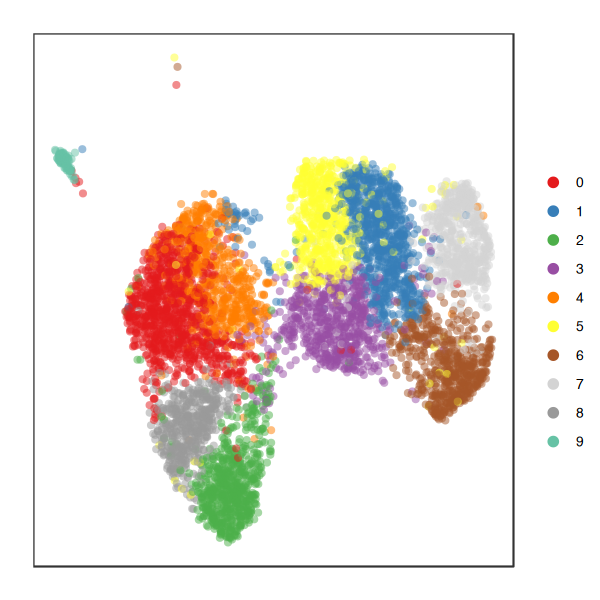

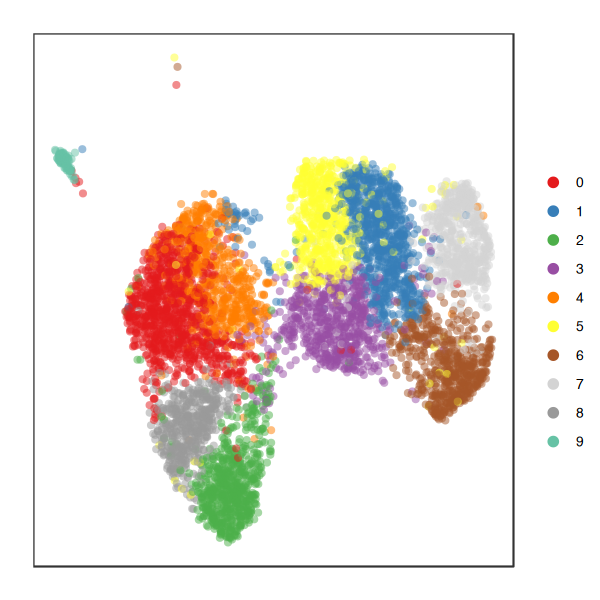

In [25]:
options(repr.plot.width = 5, repr.plot.height = 5)
g
ggsave(paste0(fig_dir,"/UMAP_Tcell.pdf"), 
       plot = g, 
       width = 5, height = 5)

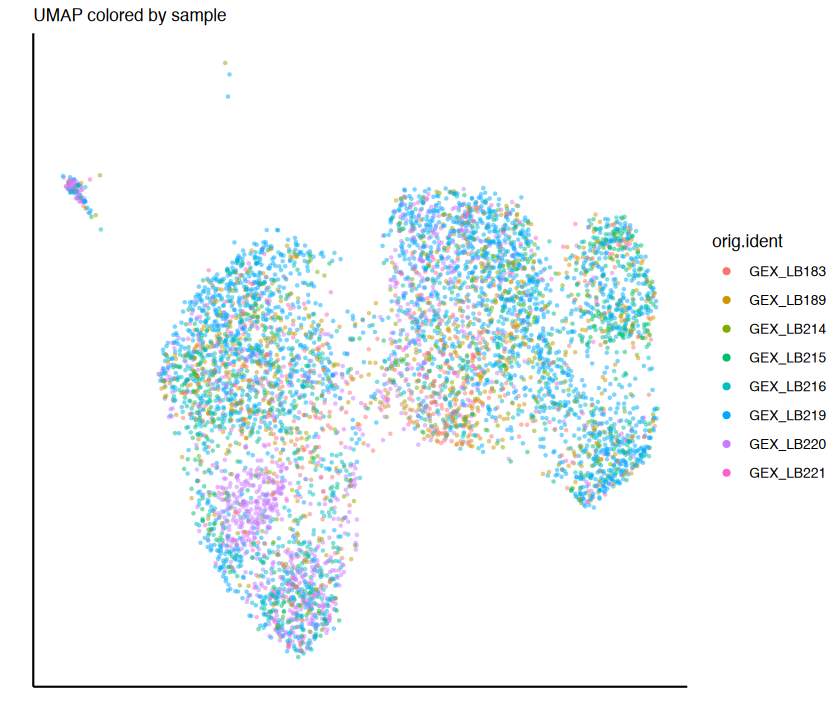

In [26]:
options(repr.plot.width = 7, repr.plot.height = 6)
filter_samples = cbind(gex_t[["umap"]]@cell.embeddings,gex_t@meta.data) %>%
  dplyr::group_by(orig.ident) %>%
  dplyr::summarise(count = dplyr::n()) %>%
  dplyr::filter(count>1) %>%
  .$orig.ident
umap_res = cbind(gex_t[["umap"]]@cell.embeddings,gex_t@meta.data) %>%
  dplyr::filter(orig.ident %in% filter_samples) %>%
  dplyr::group_by(orig.ident) %>%
  dplyr::mutate(density_sample = get_density(umap_1, umap_2, n = 100)) %>%
  dplyr::ungroup() %>%
  dplyr::group_by(seurat_clusters) %>%
  dplyr::mutate(density_seurat_clusters = get_density(umap_1, umap_2, n = 100)) %>%
  dplyr::ungroup() 
plot(ggplot() +
       geom_point(
         data = umap_res %>% dplyr::sample_frac(1L),
         mapping = aes_string(x = "umap_1", y = "umap_2", color = "orig.ident"),
         size = 1, stroke = 0, shape = 16, alpha = 0.5
       ) +
       labs(
         title = paste0("UMAP colored by sample"),
         x = "",
         y = ""
       ) +
       theme_classic(base_size = 10) +
       theme(
         legend.position = "right",
         axis.text = element_blank(),
         axis.ticks = element_blank(),
         panel.grid = element_blank(),
         plot.title = element_text(color="black", size=10, face = "italic")
       ) + guides(colour = guide_legend(override.aes = list(alpha = 1, size = 2)),
                  fill = guide_legend(override.aes = list(alpha = 1, size = 2)))
)

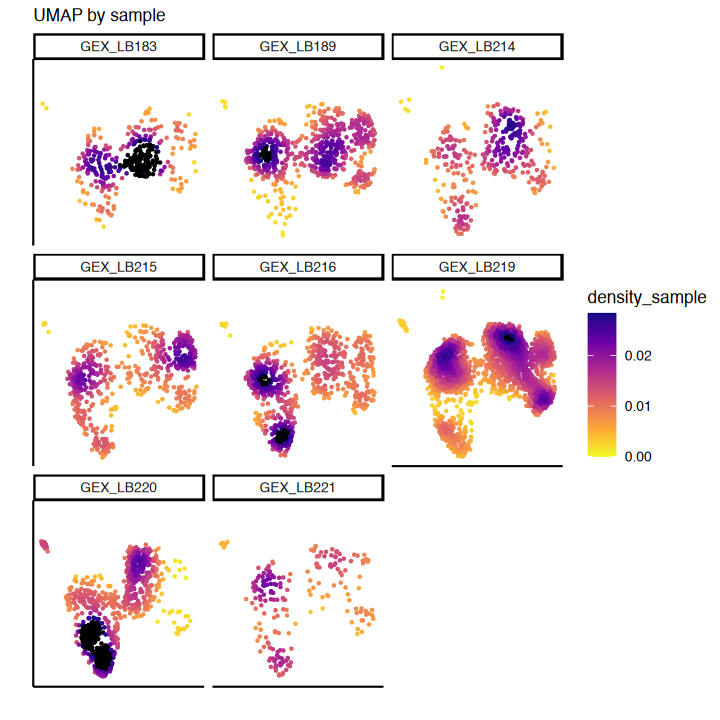

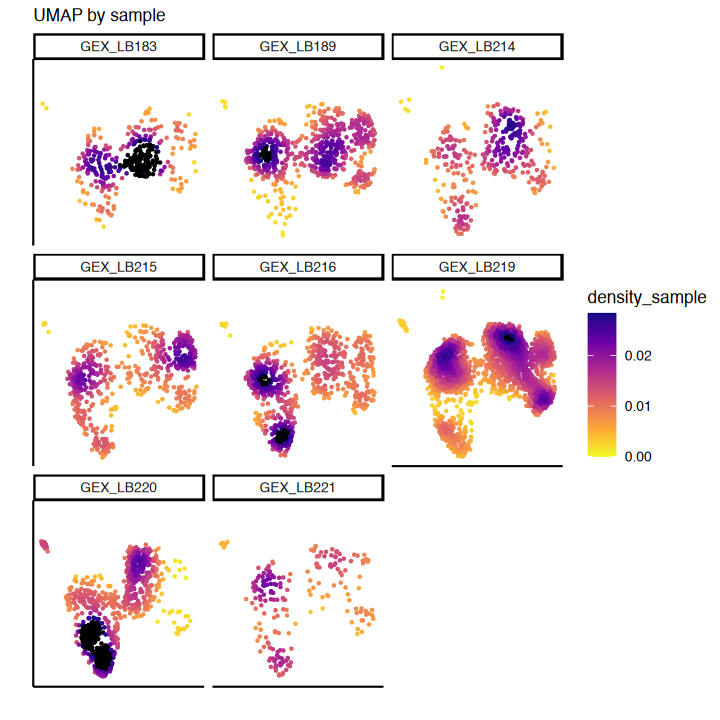

In [27]:
options(repr.plot.width = 6, repr.plot.height = 6)
g = ggplot(umap_res) +
    geom_point(aes(umap_1, umap_2, color = density_sample),
               size = 1, stroke = 0, shape = 16) + 
    scale_color_viridis_c(option = "plasma",direction = -1, na.value = "black",limits = c(0, quantile(umap_res$density_sample, probs = seq(0, 1, 0.1))["90%"])) +
    facet_wrap( ~ orig.ident, ncol =3) +
    labs(
      title = paste0("UMAP by sample"),
      x = "",
      y = ""
    ) +
    theme_classic(base_size = 10) +
    theme(
      legend.position = "right",
      axis.text = element_blank(),
      axis.ticks = element_blank(),
      panel.grid = element_blank(),
      plot.title = element_text(color="black", size=10, face = "italic")
    )
g
ggsave(paste0(fig_dir,"/UMAP_Tcell_by_sample.pdf"), 
       plot = g, 
       width = 6, height = 6)

### Figure 1D — Marker expression across T-cell subclusters

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for fill is already present.
Adding another scale

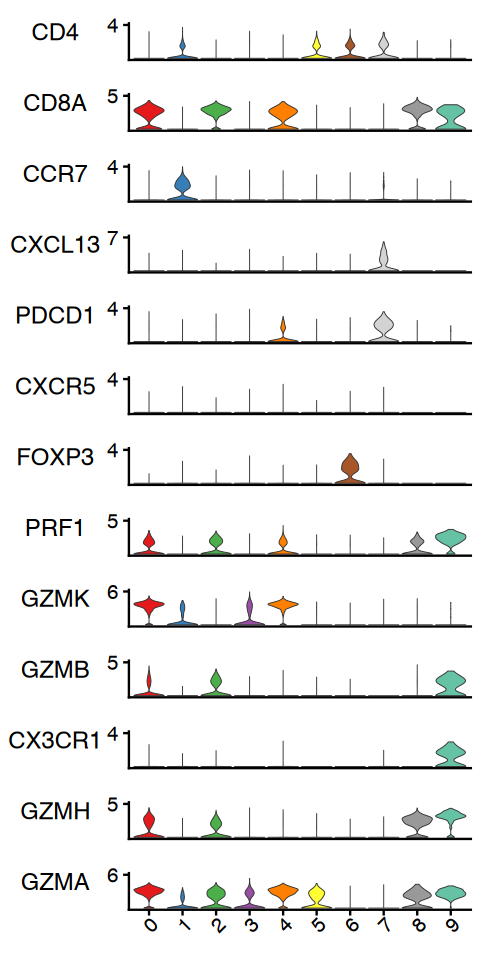

In [28]:
options(repr.plot.width = 4, repr.plot.height = 8)
g = Stacked_VlnPlot(gex_t, 
                features = c("CD4", "CD8A", "CCR7", "CXCL13", "PDCD1", "CXCR5", "FOXP3", "PRF1", 
                             "GZMK", "GZMB", "CX3CR1", "GZMH", "GZMA"

                             ), 
                x_lab_rotate = TRUE,
                vln_linewidth = 0.2,
                plot_spacing = 0.3) & 
  scale_fill_manual(values = manual_colors)
ggsave(paste0(fig_dir,"/Marker_Tcell.pdf"), 
       plot = g, 
       width = 4, height = 8)

### fig. S1A — T-cell marker heatmap

In [29]:
exp_heat <- as.data.frame(t(gex_t@assays$RNA$data[c(
  "SELL","CCR7","TCF7","CD69","IL7R","GIMAP5","LEF1", # CD69 and CXCR6: Trm
  "CD4", "CD8A", 
  "CXCR3","CXCR4","CXCR5","CXCR6","CX3CR1","CCR2","CCR4","CCR6",
  "CCL5","CCL4","CXCL13",
  "FOXP3","IL2RA",# "CD25",
  "PDCD1","CTLA4","ICOS","CD40LG", "TIGIT","LAG3",
  "MAF", # B cell help, expressed by Tph and Tfh
  "RORC",
  "GATA3",
  "TBX21",
  "HLA-DRA","HLA-DRB1",
  "B3GAT1", # CD57
  "CD27",
  "CD38",
  "ITGAE", # CD103: CD69+CD103-CD8+ Trm and CD69+CD103+CD8+ Trm [cytotoxity: CD69+CD103-CD8+ Trm > CD69+CD103+CD8+ Trm]
  "KLRB1", # CD161: MAIT cells
  "IFI44L","MX1","IFIT3",
  "ZNF683","XCL1", # Trm
  "GZMB","GZMK","GZMA","GZMH","GNLY","PRF1","NKG7","IFNG",
  "TRDV1","TRDV2","TRGV9","SLC4A10","AQP3",
  "MKI67"
),]))
exp_heat <- as.data.frame(exp_heat)
exp_heat$res_cell <- Idents(gex_t)

In [30]:
exp_ave <- aggregate(exp_heat[, 1:(ncol(exp_heat)-1)], list(exp_heat$res_cell), mean)
colnames(exp_ave)[1] <- "res_cell"
exp_ave <- as.data.frame(t(exp_ave))
colnames(exp_ave) <- as.character(t(exp_ave[1,]))
exp_ave <- exp_ave[-1,]
row_names <- rownames(exp_ave)
exp_ave <- mutate_all(exp_ave, function(x) as.numeric(as.character(x)))
rownames(exp_ave) <- row_names 
colnames(exp_ave) = paste0("T-",
                           cluster_df[cluster_df$cell == "T",] %>%
                             magrittr::set_rownames(cluster_df[cluster_df$cell == "T",]$cluster) %>%
                             .[colnames(exp_ave),] %>%
                             .$cluster,
                           ":",
                           cluster_df[cluster_df$cell == "T",] %>%
                             magrittr::set_rownames(cluster_df[cluster_df$cell == "T",]$cluster) %>%
                             .[colnames(exp_ave),] %>%
                             .$clu_name)                
head(exp_ave)
dim(exp_ave)     

,T-0:GZMB+K+A+H+CD8,T-1:CMCD4 (CCR7+),T-2:GZMB+A+H+CD8,T-3:DN,T-4:GZMK+A+CD8,T-5:Th1,T-6:Treg,T-7:Tph/Tfh,T-8:GZMH+A+CD8,T-9:CX3CR1+CD8
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
SELL,0.09545075,0.8157569,0.00000000,0.3574944,0.2048291,0.0600379,0.9347438,0.2750955,0.02123746,0.25204583
CCR7,0.09754365,1.0881163,0.05746932,0.5180850,0.2481583,0.2387632,0.3762735,0.4732469,0.03087619,0.06547124
TCF7,0.34742480,1.2073845,0.19160630,0.4238245,0.5453048,0.3421572,0.2618569,0.8703266,0.16573670,0.19580910
CD69,1.85694600,2.3381130,2.02904300,1.2778130,1.7043530,1.8793040,1.2378520,1.3658230,1.84866600,1.62261400
IL7R,0.14244260,2.0612319,0.77886870,1.3148440,0.3615520,1.3931440,0.5552138,0.5820399,0.15078540,0.55346230
GIMAP5,0.93553130,0.8290937,0.77046590,0.6875022,0.8565455,0.5493122,0.2504402,0.4118261,0.54753640,0.85415400


[1] 58 10

In [31]:
# Overwrite default draw_colnames in the pheatmap package.
# Thanks to Josh O'Brien at http://stackoverflow.com/questions/15505607
draw_colnames_45 <- function (coln, gaps, ...) {
  coord <- pheatmap:::find_coordinates(length(coln), gaps)
  x     <- coord$coord - 0.5 * coord$size
  res   <- grid::textGrob(
    coln, x = x, y = unit(1, "npc") - unit(3,"bigpts"),
    vjust = 0.75, hjust = 1, rot = 45, gp = grid::gpar(...)
  )
  return(res)
}
assignInNamespace(
  x = "draw_colnames",
  value = "draw_colnames_45",
  ns = asNamespace("pheatmap")
)
exp_ave <- as.matrix(exp_ave)
mat_breaks <- seq(min(exp_ave), max(exp_ave), length.out = 10)
quantile_breaks <- function(xs, n = 10) {
  breaks <- quantile(xs, probs = seq(0, 1, length.out = n))
  breaks[!duplicated(breaks)]
}

In [32]:
mat_breaks <- quantile_breaks(exp_ave, n = 20)
scale_rows <- function(x) t(scale(t(x)))
exp_ave_scale <- scale_rows(exp_ave) # Z-score
exp_ave_scale<- na.omit(exp_ave_scale)
mat_breaks <- quantile_breaks(exp_ave_scale, n = 10)
mat_breaks <- seq(min(exp_ave_scale), max(exp_ave_scale), length.out = 24)
mat_breaks <- quantile_breaks(exp_ave_scale, n = 6)
mat_breaks <- seq(min(exp_ave_scale), max(exp_ave_scale), length.out = 24)
exp_ave_scale[exp_ave_scale > 2] <- 2
exp_ave_scale[exp_ave_scale < -2] <- -2
head(exp_ave_scale)
dim(exp_ave_scale)

,T-0:GZMB+K+A+H+CD8,T-1:CMCD4 (CCR7+),T-2:GZMB+A+H+CD8,T-3:DN,T-4:GZMK+A+CD8,T-5:Th1,T-6:Treg,T-7:Tph/Tfh,T-8:GZMH+A+CD8,T-9:CX3CR1+CD8
SELL,-0.6342962,1.5812548,-0.92788798,0.17170994,-0.2978651,-0.7432206,1.9472403,-0.08173653,-0.8625648,-0.1526338
CCR7,-0.6885242,2.0000000,-0.81289338,0.61661049,-0.2210972,-0.2502546,0.1765038,0.47745724,-0.8954242,-0.7880597
TCF7,-0.3184845,2.0000000,-0.77918386,-0.09259798,0.2665757,-0.3340589,-0.5714780,1.22754849,-0.8556710,-0.7667577
CD69,0.4027773,1.7783085,0.89475782,-1.25281327,-0.0334464,0.4666930,-1.3670514,-1.00121558,0.3791069,-0.2671169
IL7R,-1.0492505,2.0000000,-0.01701363,0.85229937,-0.6938710,0.9792963,-0.3797656,-0.33625564,-1.0357191,-0.3826064
GIMAP5,1.1946491,0.7171422,0.45412253,0.08192565,0.8402982,-0.5380309,-1.8788489,-1.15482954,-0.5459976,0.8295693


[1] 58 10

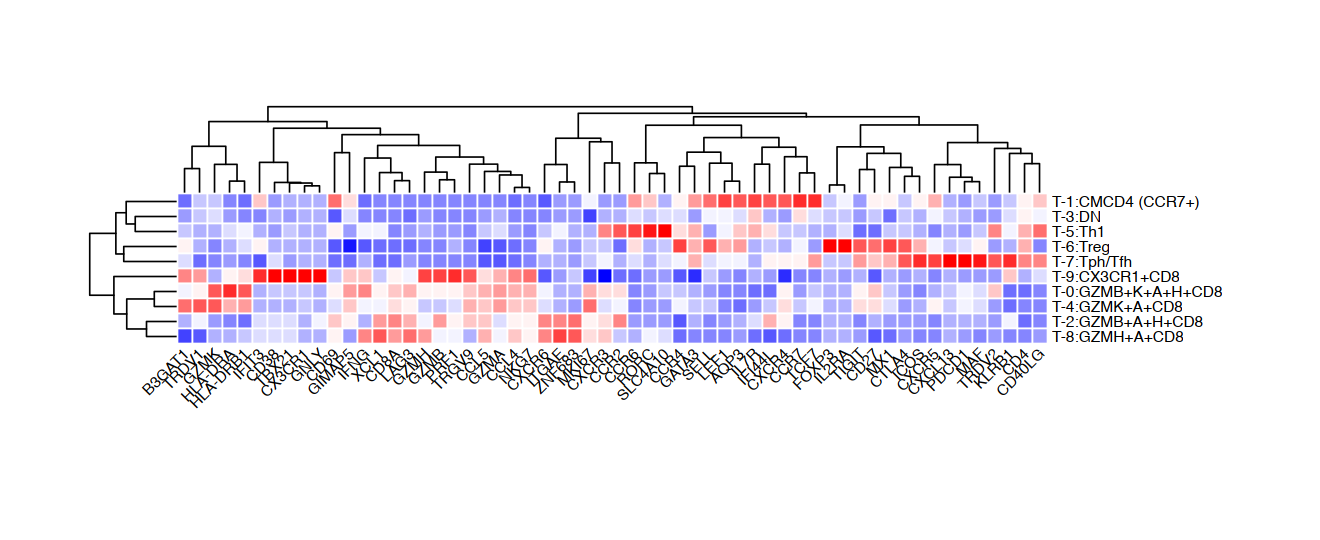

In [33]:
options(repr.plot.width = 11, repr.plot.height = 4.5)
pdf(paste0(fig_dir,"/Heatmap_Tcell.pdf"), width = 7, height = 9.1)
invisible(
  pheatmap(
    mat = scale(t(exp_ave)),
    border_color = "white",
    #breaks  = mat_breaks,
    #color  =inferno(length(mat_breaks) - 1),
    color= colorRampPalette(c("blue", "white", "red"))(length(mat_breaks)),
    show_rownames = TRUE,
    show_colnames = TRUE,
    cluster_rows = TRUE,
    cluster_cols = TRUE,
    show_row_dend = FALSE, show_column_dend = FALSE, 
    fontsize = 9,
    fontsize_row = 9,
    cellwidth = 9, cellheight = 9, 
    width = 11, height = 4.5,
    scale = "none",
    legend = FALSE
  )
)
dev.off()

In [34]:
Idents(gex) = gex@meta.data$new_cluster
cluster_COLORS <- manual_colors[1:length(unique(Idents(gex)))]
names(cluster_COLORS) = unique(Idents(gex))

In [35]:
cluster_stats <- Cluster_Stats_All_Samples(seurat_object = gex, group_by_var = "orig.ident")

Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”


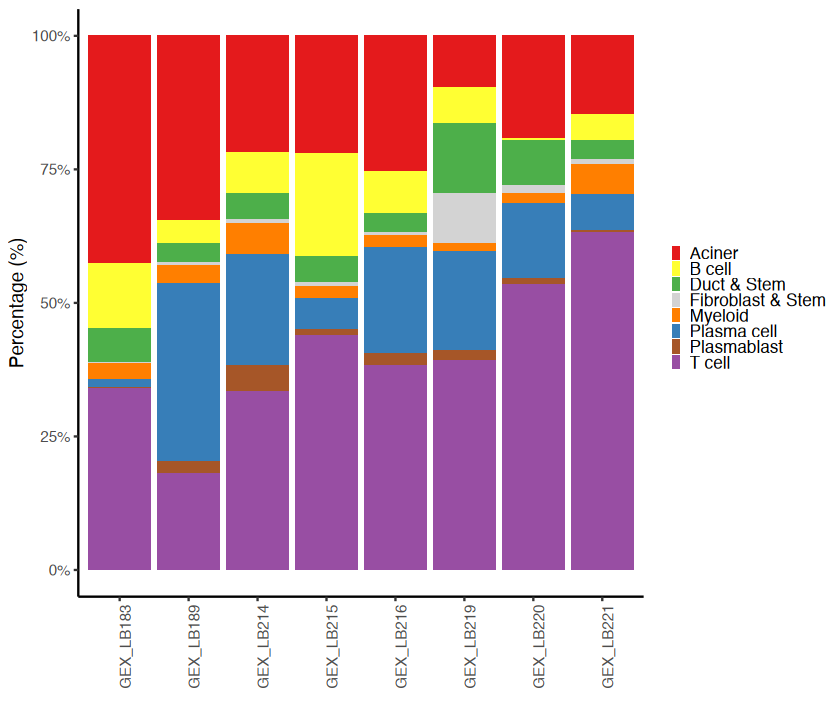

In [36]:
options(repr.plot.width = 7, repr.plot.height = 6)
g = cluster_stats[,grep("%$",colnames(cluster_stats),invert = TRUE)] %>%
  dplyr::select(-Number, -Freq) %>%
  tidyr::pivot_longer(cols = -Cluster, names_to = "Sample", values_to = "Value") %>%
  dplyr::filter(Cluster %in% unique(Idents(gex))) %>%
  dplyr::group_by(Sample) %>%
  dplyr::mutate(Percentage = Value / sum(Value) * 100) %>%
  dplyr::ungroup() %>%
  na.omit() %>%
  #dplyr::mutate(Cluster = factor(Cluster, levels = levels(Idents(ste)))) %>%
  ggplot(., aes(x = Sample, y = Percentage, fill = Cluster)) +
  geom_bar(stat = "identity") +
  scale_y_continuous(labels = scales::percent_format(scale = 1)) +
  labs(x = "", y = "Percentage (%)", fill = "Cluster") +
  scale_color_manual(values = cluster_COLORS) +
  scale_fill_manual(values = cluster_COLORS) +
  theme_classic() +
  theme(legend.position = "right",
        legend.title = element_text(size = 0),
        legend.text = element_text(size = 10),
        legend.key.size = unit(0.2, "cm"),
        axis.text.x = element_text(angle = 90, hjust = 1))
g

In [37]:
gex_t@meta.data$clu_name = gex_t@meta.data %>%
  dplyr::select(seurat_clusters) %>%
  dplyr::left_join(.,cluster_df[cluster_df$cell=="T",],by=c("seurat_clusters"="cluster")) %>%
  .$clu_name
Idents(gex_t) = gex_t@meta.data$clu_name
cluster_COLORS <- manual_colors[1:length(unique(Idents(gex_t)))]
names(cluster_COLORS) = unique(Idents(gex_t))
table(Idents(gex_t))
table(Idents(gex_t),gex_t$orig.ident)
table(gex_t$seurat_clusters,gex_t$orig.ident)
table(gex_t$clu_name,gex_t$orig.ident)
cluster_stats <- Cluster_Stats_All_Samples(seurat_object = gex_t, group_by_var = "orig.ident")


 CMCD4 (CCR7+)            Th1           Treg        Tph/Tfh   GZMB+A+H+CD8 
           880            599            573            548            679 
    GZMH+A+CD8             DN GZMB+K+A+H+CD8     GZMK+A+CD8     CX3CR1+CD8 
           475            661           1038            620             95 

                
                 GEX_LB183 GEX_LB189 GEX_LB214 GEX_LB215 GEX_LB216 GEX_LB219
  CMCD4 (CCR7+)         26        89        76        72        67       455
  Th1                   20        49        37        27        52       257
  Treg                  19        57        32        45        61       327
  Tph/Tfh               19        84        12       127        69       218
  GZMB+A+H+CD8          19        22        46        61       155       110
  GZMH+A+CD8            17         9        13        41        35        92
  DN                   146       111        55        36        71       132
  GZMB+K+A+H+CD8        63       148        39       116       196       333
  GZMK+A+CD8            22        78        29        67        40       309
  CX3CR1+CD8             2         4         2         6         7        18
                
                 GEX_LB220 GEX_LB221
  CMCD4 (CCR7+)         69        26
  Th1                  138        19
  Treg  

    
     GEX_LB183 GEX_LB189 GEX_LB214 GEX_LB215 GEX_LB216 GEX_LB219 GEX_LB220
  0         63       148        39       116       196       333       103
  1         26        89        76        72        67       455        69
  2         19        22        46        61       155       110       230
  3        146       111        55        36        71       132       103
  4         22        78        29        67        40       309        49
  5         20        49        37        27        52       257       138
  6         19        57        32        45        61       327        15
  7         19        84        12       127        69       218         5
  8         17         9        13        41        35        92       254
  9          2         4         2         6         7        18        48
  10         0         0         0         0         0         0         0
  11         0         0         0         0         0         0         0
    
     GEX_LB221


                
                 GEX_LB183 GEX_LB189 GEX_LB214 GEX_LB215 GEX_LB216 GEX_LB219
  CMCD4 (CCR7+)         26        89        76        72        67       455
  CX3CR1+CD8             2         4         2         6         7        18
  DN                   146       111        55        36        71       132
  GZMB+A+H+CD8          19        22        46        61       155       110
  GZMB+K+A+H+CD8        63       148        39       116       196       333
  GZMH+A+CD8            17         9        13        41        35        92
  GZMK+A+CD8            22        78        29        67        40       309
  Th1                   20        49        37        27        52       257
  Tph/Tfh               19        84        12       127        69       218
  Treg                  19        57        32        45        61       327
                
                 GEX_LB220 GEX_LB221
  CMCD4 (CCR7+)         69        26
  CX3CR1+CD8            48         8
  DN    

Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”


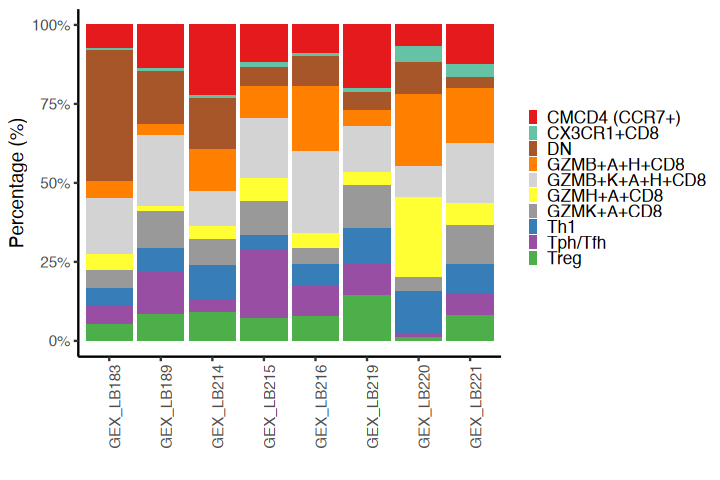

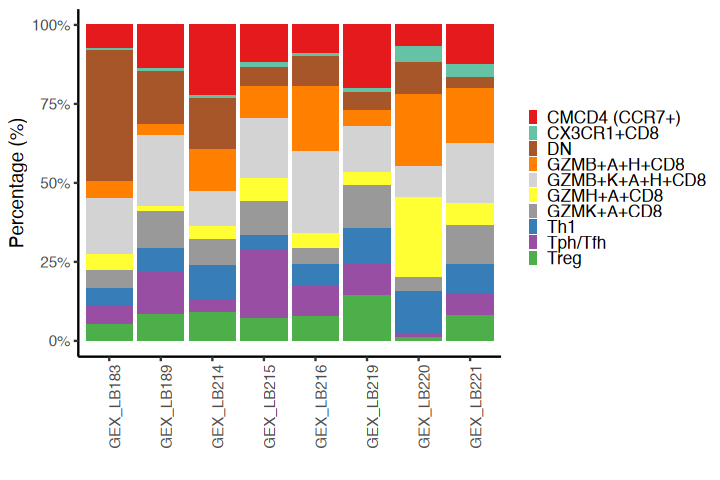

In [38]:
options(repr.plot.width = 6, repr.plot.height = 4)
g = cluster_stats[,grep("%$",colnames(cluster_stats),invert = TRUE)] %>%
  dplyr::select(-Number, -Freq) %>%
  tidyr::pivot_longer(cols = -Cluster, names_to = "Sample", values_to = "Value") %>%
  dplyr::filter(Cluster %in% unique(Idents(gex_t))) %>%
  dplyr::group_by(Sample) %>%
  dplyr::mutate(Percentage = Value / sum(Value) * 100) %>%
  dplyr::ungroup() %>%
  na.omit() %>%
  #dplyr::mutate(Cluster = factor(Cluster, levels = levels(Idents(ste)))) %>%
  ggplot(., aes(x = Sample, y = Percentage, fill = Cluster)) +
  geom_bar(stat = "identity") +
  scale_y_continuous(labels = scales::percent_format(scale = 1)) +
  labs(x = "", y = "Percentage (%)", fill = "Cluster") +
  scale_color_manual(values = cluster_COLORS) +
  scale_fill_manual(values = cluster_COLORS) +
  theme_classic() +
  theme(legend.position = "right",
        legend.title = element_text(size = 0),
        legend.text = element_text(size = 10),
        legend.key.size = unit(0.2, "cm"),
        axis.text.x = element_text(angle = 90, hjust = 1))
g
ggsave(plot = g, 
       filename = paste0(fig_dir,"/Barplot_Tcell_Cluster_by_Sample.pdf"), 
       width = 6, height = 4)

## TCR repertoire — load 10x contigs and integrate with the T cells

In [39]:
data_type = "TCR"

In [40]:
# List to store successfully loaded data frames
contig_list <- list()

In [41]:
# Loop to load CSV files
for (sample_id in sample_ids) {
  tryCatch({
    S <- read.csv(paste0(dir,"/data/",sample_id,"/",data_type,"/outs/filtered_contig_annotations.csv"))
    contig_list[[sample_id]] <- S
  }, error = function(e) {
    print(paste("Error reading CSV for sample_id =", sample_id))
  })
}

In [42]:
print("Number of sequenced TCR")
lapply(contig_list, count_seq_cells) %>%
  unlist()

[1] "Number of sequenced TCR"


LB183 LB189 LB214 LB215 LB216 LB219 LB220 LB221 
  466  1994   456   793  1019  2938  1338   266

In [43]:
print("Number of total sequenced TCR")
lapply(contig_list, count_seq_cells) %>%
  unlist() %>%
  sum()

[1] "Number of total sequenced TCR"


[1] 9270

In [44]:
head(contig_list[[1]])
contig_list_t = contig_list

,barcode,is_cell,contig_id,high_confidence,length,chain,v_gene,d_gene,j_gene,c_gene,⋯,fwr3_nt,cdr3,cdr3_nt,fwr4,fwr4_nt,reads,umis,raw_clonotype_id,raw_consensus_id,exact_subclonotype_id
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<int>
1,AAACCTGCATTTGCCC-1,true,AAACCTGCATTTGCCC-1_contig_1,true,533,TRB,TRBV6-5,,TRBJ2-3,TRBC2,⋯,ACTGACCAAGGAGAAGTCCCCAATGGCTACAATGTCTCCAGATCAACCACAGAGGATTTCCCGCTCAGGCTGCTGTCGGCTGCTCCCTCCCAGACATCTGTGTACTTC,CASSFYPQNRLAGDSDTQYF,TGTGCCAGCAGTTTCTACCCACAAAACCGCCTAGCGGGAGACTCAGATACGCAGTATTTT,GPGTRLTVL,GGCCCAGGCACCCGGCTGACAGTGCTCG,3660,5,clonotype372,clonotype372_consensus_1,1
2,AAACCTGCATTTGCCC-1,true,AAACCTGCATTTGCCC-1_contig_2,true,523,TRA,TRAV17,,TRAJ26,TRAC,⋯,AAACACAGTGGAAGATTAAGAGTCACGCTTGACACTTCCAAGAAAAGCAGTTCCTTGTTGATCACGGCTTCCCGGGCAGCAGACACTGCTTCTTACTTC,CATDDVYGQNFVF,TGTGCTACGGACGATGTCTATGGTCAGAATTTTGTCTTT,GPGTRLSVLP,GGTCCCGGAACCAGATTGTCCGTGCTGCCCT,766,2,clonotype372,clonotype372_consensus_2,1
3,AAACGGGTCATCTGTT-1,true,AAACGGGTCATCTGTT-1_contig_1,true,501,TRB,TRBV20-1,TRBD1,TRBJ1-5,TRBC1,⋯,ACATACGAGCAAGGCGTCGAGAAGGACAAGTTTCTCATCAACCATGCAAGCCTGACCTTGTCCACTCTGACAGTGACCAGTGCCCATCCTGAAGACAGCAGCTTCTACATC,CSASRDRRSNQPQHF,TGCAGTGCTAGCCGGGACAGGAGAAGCAATCAGCCCCAGCATTTT,GDGTRLSIL,GGTGATGGGACTCGACTCTCCATCCTAG,6530,9,clonotype117,clonotype117_consensus_1,1
4,AAAGATGAGCAGCGTA-1,true,AAAGATGAGCAGCGTA-1_contig_1,true,483,TRB,TRBV20-1,,TRBJ2-7,TRBC2,⋯,ACATACGAGCAAGGCGTCGAGAAGGACAAGTTTCTCATCAACCATGCAAGCCTGACCTTGTCCACTCTGACAGTGACCAGTGCCCATCCTGAAGACAGCAGCTTCTACATC,CSASSGRSYEQYV,TGCAGTGCTAGTTCGGGGAGGTCCTACGAGCAGTACGTC,GPGTRLTVT,GGGCCGGGCACCAGGCTCACGGTCACAG,2330,4,clonotype10,clonotype10_consensus_1,1
5,AAAGATGAGCAGCGTA-1,true,AAAGATGAGCAGCGTA-1_contig_2,true,586,TRA,TRAV12-1,,TRAJ4,TRAC,⋯,AATGAAGATGGAAGGTTTACAGCACAGCTCAATAGAGCCAGCCAGTATATTTCCCTGCTCATCAGAGACTCCAAGCTCAGTGATTCAGCCACCTACCTC,CVVYFFSGGYNKLIF,TGTGTGGTGTATTTCTTTTCTGGTGGCTACAATAAGCTGATTTTT,GAGTRLAVHP,GGAGCAGGGACCAGGCTGGCTGTACACCCAT,2298,2,clonotype10,clonotype10_consensus_2,1
6,AAAGCAATCTTGGGTA-1,true,AAAGCAATCTTGGGTA-1_contig_1,true,520,TRA,TRAV26-1,,TRAJ39,TRAC,⋯,GAAACCAATGAAATGGCCTCTCTGATCATCACAGAAGACAGAAAGTCCAGCACCTTGATCCTGCCCCACGCTACGCTGAGAGACACTGCTGTGTACTAT,CIAPRAGNMLTF,TGCATCGCCCCGAGGGCAGGCAACATGCTCACCTTT,GGGTRLMVKP,GGAGGGGGAACAAGGTTAATGGTCAAACCCC,2910,3,clonotype324,clonotype324_consensus_2,1


In [45]:
combined <- combineTCR(contig_list, 
                       samples = sample_ids, 
                       ID = sample_ids)

In [46]:
combined <- addVariable(combined, 
                        name = "batch", 
                        variables = sample_ids)

In [47]:
print(combined[[1]][1:5,ncol(combined[[1]])]) # This is showing the first 5 values of the new column added

[1] "LB183" "LB183" "LB183" "LB183" "LB183"


In [48]:
print(head(combined[[1]]))
print("TRAV")
print(head(sort(table(combined[[1]]$cdr3_aa1), decreasing = TRUE)))
print("TRBV")
print(head(sort(table(combined[[1]]$cdr3_aa2), decreasing = TRUE)))
print("VDJC gene sequence")
print(head(sort(table(combined[[1]]$CTaa), decreasing = TRUE)))

                          barcode sample    ID                 TCR1
1  LB183_LB183_AAACCTGCATTTGCCC-1  LB183 LB183   TRAV17.TRAJ26.TRAC
3  LB183_LB183_AAACGGGTCATCTGTT-1  LB183 LB183                 <NA>
4  LB183_LB183_AAAGATGAGCAGCGTA-1  LB183 LB183  TRAV12-1.TRAJ4.TRAC
6  LB183_LB183_AAAGCAATCTTGGGTA-1  LB183 LB183 TRAV26-1.TRAJ39.TRAC
8  LB183_LB183_AAATGCCAGAGAACAG-1  LB183 LB183   TRAV40.TRAJ33.TRAC
10 LB183_LB183_AACACGTCAGGGCATA-1  LB183 LB183   TRAV8-6.TRAJ5.TRAC
           cdr3_aa1                                         cdr3_nt1
1     CATDDVYGQNFVF          TGTGCTACGGACGATGTCTATGGTCAGAATTTTGTCTTT
3              <NA>                                             <NA>
4   CVVYFFSGGYNKLIF    TGTGTGGTGTATTTCTTTTCTGGTGGCTACAATAAGCTGATTTTT
6      CIAPRAGNMLTF             TGCATCGCCCCGAGGGCAGGCAACATGCTCACCTTT
8     CLPQLDSNYQLIW          TGTCTTCCGCAATTGGATAGCAACTATCAGTTAATCTGG
10 CAVSDCMDTGRRALTF TGTGCTGTGAGTGATTGCATGGACACGGGCAGGAGAGCACTTACTTTT
                           TCR2          

In [49]:
TCR <- combineTCR(contig_list_t,
                  samples = sample_ids, 
                  ID = sample_ids)
for (i in seq_along(TCR)) {
  TCR[[i]] <- stripBarcode(TCR[[i]], column = 1, connector = "_", num_connects = 3)
}
head(TCR[[1]])

,barcode,sample,ID,TCR1,cdr3_aa1,cdr3_nt1,TCR2,cdr3_aa2,cdr3_nt2,CTgene,CTnt,CTaa,CTstrict,cellType
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,AAACCTGCATTTGCCC-1,LB183,LB183,TRAV17.TRAJ26.TRAC,CATDDVYGQNFVF,TGTGCTACGGACGATGTCTATGGTCAGAATTTTGTCTTT,TRBV6-5.NA.TRBJ2-3.TRBC2,CASSFYPQNRLAGDSDTQYF,TGTGCCAGCAGTTTCTACCCACAAAACCGCCTAGCGGGAGACTCAGATACGCAGTATTTT,TRAV17.TRAJ26.TRAC_TRBV6-5.NA.TRBJ2-3.TRBC2,TGTGCTACGGACGATGTCTATGGTCAGAATTTTGTCTTT_TGTGCCAGCAGTTTCTACCCACAAAACCGCCTAGCGGGAGACTCAGATACGCAGTATTTT,CATDDVYGQNFVF_CASSFYPQNRLAGDSDTQYF,TRAV17.TRAJ26.TRAC_TGTGCTACGGACGATGTCTATGGTCAGAATTTTGTCTTT_TRBV6-5.NA.TRBJ2-3.TRBC2_TGTGCCAGCAGTTTCTACCCACAAAACCGCCTAGCGGGAGACTCAGATACGCAGTATTTT,T-AB
3,AAACGGGTCATCTGTT-1,LB183,LB183,NA,NA,NA,TRBV20-1.TRBD1.TRBJ1-5.TRBC1,CSASRDRRSNQPQHF,TGCAGTGCTAGCCGGGACAGGAGAAGCAATCAGCCCCAGCATTTT,NA_TRBV20-1.TRBD1.TRBJ1-5.TRBC1,NA_TGCAGTGCTAGCCGGGACAGGAGAAGCAATCAGCCCCAGCATTTT,NA_CSASRDRRSNQPQHF,NA_NA_TRBV20-1.TRBD1.TRBJ1-5.TRBC1_TGCAGTGCTAGCCGGGACAGGAGAAGCAATCAGCCCCAGCATTTT,T-AB
4,AAAGATGAGCAGCGTA-1,LB183,LB183,TRAV12-1.TRAJ4.TRAC,CVVYFFSGGYNKLIF,TGTGTGGTGTATTTCTTTTCTGGTGGCTACAATAAGCTGATTTTT,TRBV20-1.NA.TRBJ2-7.TRBC2,CSASSGRSYEQYV,TGCAGTGCTAGTTCGGGGAGGTCCTACGAGCAGTACGTC,TRAV12-1.TRAJ4.TRAC_TRBV20-1.NA.TRBJ2-7.TRBC2,TGTGTGGTGTATTTCTTTTCTGGTGGCTACAATAAGCTGATTTTT_TGCAGTGCTAGTTCGGGGAGGTCCTACGAGCAGTACGTC,CVVYFFSGGYNKLIF_CSASSGRSYEQYV,TRAV12-1.TRAJ4.TRAC_TGTGTGGTGTATTTCTTTTCTGGTGGCTACAATAAGCTGATTTTT_TRBV20-1.NA.TRBJ2-7.TRBC2_TGCAGTGCTAGTTCGGGGAGGTCCTACGAGCAGTACGTC,T-AB
6,AAAGCAATCTTGGGTA-1,LB183,LB183,TRAV26-1.TRAJ39.TRAC,CIAPRAGNMLTF,TGCATCGCCCCGAGGGCAGGCAACATGCTCACCTTT,TRBV12-3.TRBD2.TRBJ2-1.TRBC2,CASRIGTSGGYNEQFF,TGTGCCAGCAGGATCGGGACTAGCGGGGGTTACAATGAGCAGTTCTTC,TRAV26-1.TRAJ39.TRAC_TRBV12-3.TRBD2.TRBJ2-1.TRBC2,TGCATCGCCCCGAGGGCAGGCAACATGCTCACCTTT_TGTGCCAGCAGGATCGGGACTAGCGGGGGTTACAATGAGCAGTTCTTC,CIAPRAGNMLTF_CASRIGTSGGYNEQFF,TRAV26-1.TRAJ39.TRAC_TGCATCGCCCCGAGGGCAGGCAACATGCTCACCTTT_TRBV12-3.TRBD2.TRBJ2-1.TRBC2_TGTGCCAGCAGGATCGGGACTAGCGGGGGTTACAATGAGCAGTTCTTC,T-AB
8,AAATGCCAGAGAACAG-1,LB183,LB183,TRAV40.TRAJ33.TRAC,CLPQLDSNYQLIW,TGTCTTCCGCAATTGGATAGCAACTATCAGTTAATCTGG,TRBV12-4.NA.TRBJ2-2.TRBC2,CASSLAIAGYTGELFF,TGTGCCAGCAGTTTGGCCATAGCGGGGTACACCGGGGAGCTGTTTTTT,TRAV40.TRAJ33.TRAC_TRBV12-4.NA.TRBJ2-2.TRBC2,TGTCTTCCGCAATTGGATAGCAACTATCAGTTAATCTGG_TGTGCCAGCAGTTTGGCCATAGCGGGGTACACCGGGGAGCTGTTTTTT,CLPQLDSNYQLIW_CASSLAIAGYTGELFF,TRAV40.TRAJ33.TRAC_TGTCTTCCGCAATTGGATAGCAACTATCAGTTAATCTGG_TRBV12-4.NA.TRBJ2-2.TRBC2_TGTGCCAGCAGTTTGGCCATAGCGGGGTACACCGGGGAGCTGTTTTTT,T-AB
10,AACACGTCAGGGCATA-1,LB183,LB183,TRAV8-6.TRAJ5.TRAC,CAVSDCMDTGRRALTF,TGTGCTGTGAGTGATTGCATGGACACGGGCAGGAGAGCACTTACTTTT,TRBV2.NA.TRBJ2-1.TRBC2,CASRPGTSPRNEQFF,TGTGCCAGCAGGCCTGGGACTAGCCCTCGGAATGAGCAGTTCTTC,TRAV8-6.TRAJ5.TRAC_TRBV2.NA.TRBJ2-1.TRBC2,TGTGCTGTGAGTGATTGCATGGACACGGGCAGGAGAGCACTTACTTTT_TGTGCCAGCAGGCCTGGGACTAGCCCTCGGAATGAGCAGTTCTTC,CAVSDCMDTGRRALTF_CASRPGTSPRNEQFF,TRAV8-6.TRAJ5.TRAC_TGTGCTGTGAGTGATTGCATGGACACGGGCAGGAGAGCACTTACTTTT_TRBV2.NA.TRBJ2-1.TRBC2_TGTGCCAGCAGGCCTGGGACTAGCCCTCGGAATGAGCAGTTCTTC,T-AB


In [50]:
list.receptors <- TCR

In [51]:
list.receptors = lapply(list.receptors, function(df) {
  df$barcode <- paste(df$sample, df$barcode, sep = "_")
  
  return(df)
})

In [52]:
seurat_t <- combineExpression(list.receptors, 
                              gex_t, 
                              cloneCall = "strict", 
                              chain = "both",
                              group.by = "sample", 
                              proportion = FALSE, 
                              cloneTypes=c(Single=1, Small=5, Medium=20, Large=100, Hyperexpanded=500))

In [53]:
t_clone = read.table(paste0(dir,"/output/TCR_contig_Frequency_Sequence_merged.txt"),sep="\t",header=TRUE)
t_clone_ = read.csv(paste0(dir,"/20241213_TCRbarcode_Inamo.csv"))
head(t_clone)
tail(t_clone)
head(t_clone_)
tail(t_clone_)
table(t_clone$clusters_T)
table(t_clone_$clusters_T)

,barcode,orig.ident,clusters_all,clusters_T,Frequency.of.clonotypes,cloneType.group,is_cell,contig_id,high_confidence,length,⋯,KRT5,KRT14,TP63,CAV1,ACTA2,CDH5,MCAM,nCount_RNA,nFeature_RNA,percent.mt
,<chr>,<chr>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<int>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>
1,LB220_AAAGATGCACTGTGTA-1,GEX_LB220,1,8,268,Hyperexpanded (100 < X <= 500),true,AAAGATGCACTGTGTA-1_contig_1,true,466,⋯,0,0,0,0,0,0,0,1409,807,6.600426
2,LB220_AAAGATGCACTGTGTA-1,GEX_LB220,1,8,268,Hyperexpanded (100 < X <= 500),true,AAAGATGCACTGTGTA-1_contig_2,true,472,⋯,0,0,0,0,0,0,0,1409,807,6.600426
3,LB220_AAAGCAAGTAGCCTAT-1,GEX_LB220,1,8,268,Hyperexpanded (100 < X <= 500),true,AAAGCAAGTAGCCTAT-1_contig_1,true,481,⋯,0,0,0,0,0,0,0,1910,1000,1.832461
4,LB220_AAAGCAAGTAGCCTAT-1,GEX_LB220,1,8,268,Hyperexpanded (100 < X <= 500),true,AAAGCAAGTAGCCTAT-1_contig_2,true,477,⋯,0,0,0,0,0,0,0,1910,1000,1.832461
5,LB220_AAATGCCGTAGCGTGA-1,GEX_LB220,1,8,268,Hyperexpanded (100 < X <= 500),true,AAATGCCGTAGCGTGA-1_contig_1,true,481,⋯,0,0,0,0,0,0,0,2152,1153,0.464684
6,LB220_AAATGCCGTAGCGTGA-1,GEX_LB220,1,8,268,Hyperexpanded (100 < X <= 500),true,AAATGCCGTAGCGTGA-1_contig_2,true,488,⋯,0,0,0,0,0,0,0,2152,1153,0.464684


,barcode,orig.ident,clusters_all,clusters_T,Frequency.of.clonotypes,cloneType.group,is_cell,contig_id,high_confidence,length,⋯,KRT5,KRT14,TP63,CAV1,ACTA2,CDH5,MCAM,nCount_RNA,nFeature_RNA,percent.mt
,<chr>,<chr>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<int>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>
16981,NA,GEX_LB189,4,NA,NA,NA,true,TTTCCTCCAGGTGGAT-1_contig_2,true,493,⋯,0,0,0.0000000,0,0,0,0,10582,1610,0.8599509
16982,NA,GEX_LB189,9,NA,NA,NA,true,TTTCCTCGTCCGAATT-1_contig_1,true,618,⋯,0,0,0.0000000,0,0,0,0,12039,2057,1.3622394
16983,NA,GEX_LB189,9,NA,NA,NA,true,TTTCCTCGTCCGAATT-1_contig_2,true,492,⋯,0,0,0.0000000,0,0,0,0,12039,2057,1.3622394
16984,NA,GEX_LB219,5,NA,NA,NA,true,TTTGCGCAGCGCTTAT-1_contig_1,true,488,⋯,0,0,0.3492776,0,0,0,0,23921,3843,0.4974708
16985,NA,GEX_LB219,5,NA,NA,NA,true,TTTGCGCAGCGCTTAT-1_contig_2,true,492,⋯,0,0,0.3492776,0,0,0,0,23921,3843,0.4974708
16986,NA,GEX_LB219,5,NA,NA,NA,true,TTTGCGCAGCGCTTAT-1_contig_3,true,492,⋯,0,0,0.3492776,0,0,0,0,23921,3843,0.4974708


,original_rownumber,ID,HLA,response,barcode,orig.ident,clusters_all,clusters_T,Frequency.of.clonotypes,cloneType.group,⋯,KRT5,KRT14,TP63,CAV1,ACTA2,CDH5,MCAM,nCount_RNA,nFeature_RNA,percent.mt
,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>
1,5910,LB183-01,,,LB183_CGGAGCTTCCGCATAA-1,GEX_LB183,1,5,2,Small (1 < X <= 5),⋯,0,0,0,0,0,0,0,1454,656,0.0000000
2,5911,LB183-01,,,LB183_CGGAGCTTCCGCATAA-1,GEX_LB183,1,5,2,Small (1 < X <= 5),⋯,0,0,0,0,0,0,0,1454,656,0.0000000
3,6554,LB183-01,,,LB183_TAAGAGAAGCCAGTAG-1,GEX_LB183,1,5,2,Small (1 < X <= 5),⋯,0,0,0,0,0,0,0,685,445,0.4379562
4,6555,LB183-01,,,LB183_TAAGAGAAGCCAGTAG-1,GEX_LB183,1,5,2,Small (1 < X <= 5),⋯,0,0,0,0,0,0,0,685,445,0.4379562
5,6661,LB183-02,DRB1*14:06,Ro60,LB183_TCAGCAACAAGTCATC-1,GEX_LB183,1,5,2,Small (1 < X <= 5),⋯,0,0,0,0,0,0,0,833,529,2.6410564
6,6018,LB183-02,DRB1*14:06,Ro60,LB183_CTCGTACAGATATGGT-1,GEX_LB183,1,5,2,Small (1 < X <= 5),⋯,0,0,0,0,0,0,0,1435,808,0.6271777


,original_rownumber,ID,HLA,response,barcode,orig.ident,clusters_all,clusters_T,Frequency.of.clonotypes,cloneType.group,⋯,KRT5,KRT14,TP63,CAV1,ACTA2,CDH5,MCAM,nCount_RNA,nFeature_RNA,percent.mt
,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>
16981,13419,,,,LB221_GGGCATCGTAGAGCTG-1,GEX_LB221,3,10,1,Single (0 < X <= 1),⋯,0,0,0,0,0,0,0,1123,756,6.411398
16982,12690,,,,LB221_GCATGTAAGAATCTCC-1,GEX_LB221,3,2,1,Single (0 < X <= 1),⋯,0,0,0,0,0,0,0,1719,795,1.163467
16983,11984,,,,LB221_GAACCTAAGTGACTCT-1,GEX_LB221,1,3,1,Single (0 < X <= 1),⋯,0,0,0,0,0,0,0,2252,1190,1.776199
16984,7344,,,,LB221_AATCCAGCAGCCTTGG-1,GEX_LB221,3,2,1,Single (0 < X <= 1),⋯,0,0,0,0,0,0,0,2518,1221,1.707705
16985,6992,,,,LB221_AAAGCAAAGAGTACAT-1,GEX_LB221,1,0,1,Single (0 < X <= 1),⋯,0,0,0,0,0,0,0,5066,1834,1.362021
16986,13845,,,,LB221_GTCGTAACAGCCTTTC-1,GEX_LB221,1,0,1,Single (0 < X <= 1),⋯,0,0,0,0,0,0,0,3531,1664,1.387709



   0    1    2    3    4    5    6    7    8    9 
1996 1741 1377 1220 1156 1202 1183 1106  898  187 


   0    1    2    3    4    5    6    7    8    9   10   11 
1944 1470 1275 1273 1163 1122 1060 1000  564  549  427  216 

In [54]:
# just checking
setdiff(t_clone_$barcode,t_clone$barcode)
setdiff(t_clone$barcode,t_clone_$barcode)
all(na.omit(t_clone[t_clone_$original_rownumber,]$barcode) == na.omit(t_clone_$barcode))

character(0)

character(0)

[1] TRUE

In [55]:
# update all_clone and t_clone
t_clone_$clusters_all = t_clone[t_clone_$original_rownumber,]$clusters_all
t_clone_$clusters_T = t_clone[t_clone_$original_rownumber,]$clusters_T
table(t_clone_$clusters_all)
table(t_clone_$clusters_T)


   0    1    2    3    4    5    6    7    8    9   10   11   12   13   14   15 
 204 7562 7573  276  201  205   40  192   89  397   83   50   67    2   27    7 
  16 
  11 


   0    1    2    3    4    5    6    7    8    9 
1996 1741 1377 1220 1156 1202 1183 1106  898  187 

In [56]:
# clusters_all == "2" equal to CD4T
round(100 * (table(t_clone_[t_clone_$clusters_all == "2",]$clusters_T) / table(t_clone_[t_clone_$clusters_all == "2" | t_clone_$clusters_all == "1",]$clusters_T)), digits = 2)


    0     1     2     3     4     5     6     7     8     9 
 1.80 96.03  5.07 89.13  6.32 80.45 98.73 99.46  0.67  0.53 

In [57]:
# clusters_all == "1" equal to CD8T
round(100 * (table(t_clone_[t_clone_$clusters_all == "1",]$clusters_T) / table(t_clone_[t_clone_$clusters_all == "2" | t_clone_$clusters_all == "1",]$clusters_T)), digits = 2)


    0     1     2     3     4     5     6     7     8     9 
98.20  3.97 94.93 10.87 93.68 19.55  1.27  0.54 99.33 99.47 

In [58]:
table(t_clone_$ID)
table(t_clone_$response)
table(t_clone_$ID,t_clone_$response)


         LB183-01 LB183-02 LB183-03 LB183-04 LB183-05 LB183-06 LB189-01 
   16097        4        4        4        4        4        4        4 
LB189-02 LB189-03 LB189-04 LB189-05 LB189-06 LB189-07 LB189-08 LB189-09 
       2        2        4        4        4        4        4        4 
LB189-10 LB189-11 LB189-12 LB189-13 LB189-14 LB189-15 LB189-16 LB189-17 
       4        6        4        4        2        4        4        8 
LB189-18 LB189-19 LB189-20 LB189-21 LB189-22 LB189-23 LB189-24 LB189-25 
       6        6        6        6        4        4        4        4 
LB189-26 LB189-27 LB189-28 LB189-29 LB189-30 LB189-31 LB189-32 LB189-33 
       6        4        4        4        4        4        4        2 
LB189-34 LB189-35 LB215-01 LB215-02 LB215-03 LB215-04 LB215-05 LB215-06 
       4        6       10        8        8        6        4        4 
LB215-07 LB215-08 LB215-09 LB215-10 LB215-11 LB215-12 LB215-13 LB216-01 
       4        4        4        6        4      


       Ro60 
16927    59 

          
                  Ro60
           16097     0
  LB183-01     4     0
  LB183-02     0     4
  LB183-03     4     0
  LB183-04     4     0
  LB183-05     4     0
  LB183-06     4     0
  LB189-01     4     0
  LB189-02     2     0
  LB189-03     2     0
  LB189-04     4     0
  LB189-05     4     0
  LB189-06     4     0
  LB189-07     4     0
  LB189-08     0     4
  LB189-09     4     0
  LB189-10     4     0
  LB189-11     6     0
  LB189-12     4     0
  LB189-13     4     0
  LB189-14     2     0
  LB189-15     4     0
  LB189-16     4     0
  LB189-17     8     0
  LB189-18     6     0
  LB189-19     6     0
  LB189-20     0     6
  LB189-21     6     0
  LB189-22     4     0
  LB189-23     4     0
  LB189-24     4     0
  LB189-25     4     0
  LB189-26     6     0
  LB189-27     4     0
  LB189-28     4     0
  LB189-29     4     0
  LB189-30     4     0
  LB189-31     4     0
  LB189-32     4     0
  LB189-33     2     0
  LB189-34     4     0
  LB189-35     6     0


In [59]:
gex_t@meta.data %>%
  dplyr::group_by(orig.ident) %>%
  dplyr::summarize(total_cells = dplyr::n())

orig.ident,total_cells
<chr>,<int>
GEX_LB183,353
GEX_LB189,651
GEX_LB214,341
GEX_LB215,598
GEX_LB216,753
GEX_LB219,2251
GEX_LB220,1014
GEX_LB221,207


In [60]:
gex_t_full = gex_t

In [61]:
# "The presence of LB215, LB216 and LB221 in Figure 6 is irrelevant since no TCR specificities were identified in these 3 patients."
gex_t = subset(gex_t, orig.ident %in% c("GEX_LB183",
                                        "GEX_LB189",
                                        #"GEX_LB215", # no TCR specificities were identified 
                                        #"GEX_LB216", # no TCR specificities were identified 
                                        "GEX_LB219",
                                        #"GEX_LB221", # no TCR specificities were identified 
                                        "GEX_LB214",
                                        "GEX_LB220"))
total_cd4t_count_df = t_clone_ %>%
  dplyr::filter(orig.ident %in% c("GEX_LB183",
                                        "GEX_LB189",
                                        #"GEX_LB215", # no TCR specificities were identified 
                                        #"GEX_LB216", # no TCR specificities were identified 
                                        "GEX_LB219",
                                        #"GEX_LB221", # no TCR specificities were identified 
                                        "GEX_LB214",
                                        "GEX_LB220")) %>%
  dplyr::filter(clusters_all == "2") %>% # CD4T-enriched ALL-cluster
  merge(.,cluster_df[cluster_df$cell=="T",],by.x="clusters_T",by.y="cluster") %>%
  dplyr::filter(!grepl("CD8$",clu_name) & !grepl("DN$",clu_name) & !grepl("MT+",clu_name) & !grepl("replicating",clu_name)) %>%
  dplyr::group_by(orig.ident) %>%
  dplyr::summarize(total_cells = dplyr::n())
total_cd4t_count_df

orig.ident,total_cells
<chr>,<int>
GEX_LB183,144
GEX_LB189,550
GEX_LB214,310
GEX_LB219,2300
GEX_LB220,427


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


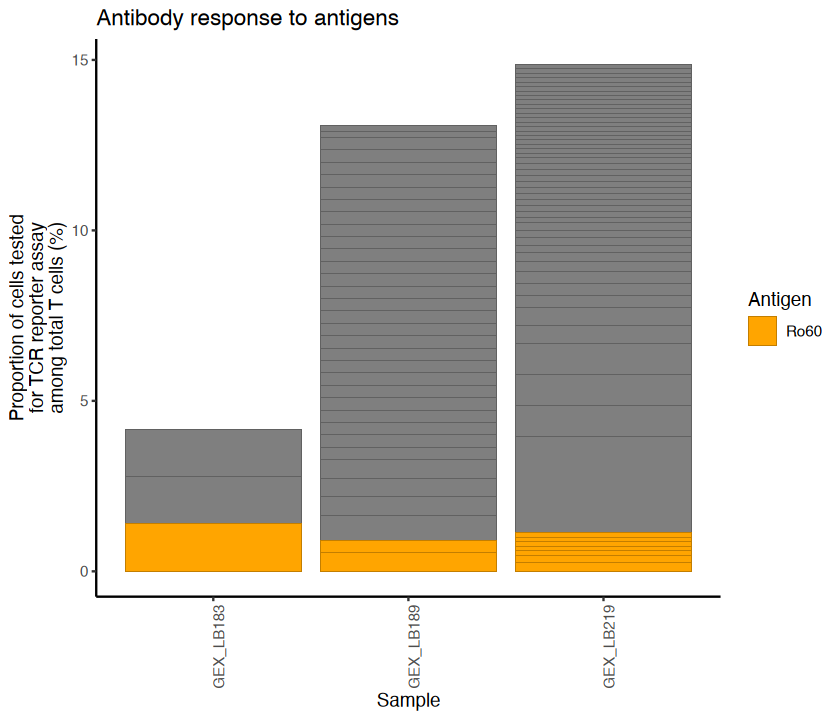

In [62]:
options(repr.plot.width = 7, repr.plot.height = 6)
t_clone_ %>%
  dplyr::filter(orig.ident %in% c("GEX_LB183",
                                  "GEX_LB189",
                                  #"GEX_LB215", # no TCR specificities were identified 
                                  #"GEX_LB216", # no TCR specificities were identified 
                                  "GEX_LB219",
                                  #"GEX_LB221", # no TCR specificities were identified 
                                  "GEX_LB214",
                                  "GEX_LB220")) %>%
  dplyr::filter(clusters_all == "2") %>% # CD4T-enriched ALL-cluster
  merge(.,cluster_df[cluster_df$cell=="T",],by.x="clusters_T",by.y="cluster") %>%
  dplyr::filter(!grepl("CD8$",clu_name) & !grepl("DN$",clu_name) & !grepl("MT+",clu_name) & !grepl("replicating",clu_name)) %>% # CD4T-subclusters in T-cluster
  dplyr::filter(ID!="") %>% # tested clones for TCR reporter assay
  dplyr::left_join(.,total_cd4t_count_df,by="orig.ident") %>%
  dplyr::mutate(proportion = 100 * (Frequency.of.clonotypes / total_cells)) %>%
  dplyr::arrange(-proportion) %>%
  dplyr::distinct(clusters_T, ID, HLA, response, orig.ident, proportion, Frequency.of.clonotypes, combination.of.the.nucleotide.and.gene.sequence.CTstrict.) %>%
  ggplot(., aes(x = orig.ident, y = proportion, fill = response)) +
  geom_bar(stat = "identity", position = "stack", size=0.05, color = "black") +
  scale_fill_manual(values = c("Ro60" = "orange")) +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1)) +
  labs(title = "Antibody response to antigens", 
       y = "Proportion of cells tested\nfor TCR reporter assay\namong total T cells (%)", 
       x = "Sample", fill = "Antigen", color = "Top nodes")

## Figure 6A — Ro60-reactive clonotypes on the T-cell UMAP

In [63]:
options(repr.plot.width = 7, repr.plot.height = 6)
tested_t = t_clone_ %>%
  dplyr::filter(orig.ident %in% c("GEX_LB183",
                                  "GEX_LB189",
                                  #"GEX_LB215", # no TCR specificities were identified 
                                  #"GEX_LB216", # no TCR specificities were identified 
                                  "GEX_LB219",
                                  #"GEX_LB221", # no TCR specificities were identified 
                                  "GEX_LB214",
                                  "GEX_LB220")) %>%
  dplyr::filter(clusters_all == "2") %>% # CD4T-enriched ALL-cluster
  merge(.,cluster_df[cluster_df$cell=="T",],by.x="clusters_T",by.y="cluster") %>%
  dplyr::filter(!grepl("CD8$",clu_name) & !grepl("DN$",clu_name) & !grepl("MT+",clu_name) & !grepl("replicating",clu_name)) %>% # CD4T-subclusters in T-cluster
  dplyr::filter(ID!="") %>%
  #dplyr::filter(response=="Ro60") %>%
  .$combination.of.the.nucleotide.and.gene.sequence.CTstrict. %>% unique()
seurat_t <- highlightClonotypes(seurat_t, 
                                cloneCall= "strict", 
                                sequence = tested_t)
seurat_t_full = seurat_t
seurat_t = subset(seurat_t, orig.ident %in% c("GEX_LB183",
                                                   "GEX_LB189",
                                                   #"GEX_LB215", # no TCR specificities were identified 
                                                   #"GEX_LB216", # no TCR specificities were identified 
                                                   "GEX_LB219",
                                                   #"GEX_LB221", # no TCR specificities were identified 
                                                   "GEX_LB214",
                                                   "GEX_LB220"))
table(seurat_t@meta.data$orig.ident)
g0 = ggplot() +
  geom_point(
    data = cbind(seurat_t[["umap"]]@cell.embeddings,
                 seurat_t@meta.data) %>% 
      dplyr::mutate(highlight = ifelse(!is.na(highlight),highlight,"hide")) %>%
      dplyr::filter(highlight == "hide"),
    mapping = aes_string(x = "umap_1", y = "umap_2"),
    size = 1, stroke = 0.01, shape = 21, alpha = 0.5, color = "grey75", fill = "grey95"
  ) +
  geom_point(
    data = cbind(seurat_t[["umap"]]@cell.embeddings,
                 seurat_t@meta.data) %>% 
      dplyr::mutate(highlight = ifelse(!is.na(highlight),highlight,"hide")) %>%
      dplyr::filter(highlight != "hide"),
    mapping = aes_string(x = "umap_1", y = "umap_2"),
    size = 2, stroke = 0, shape = 16, alpha = 0.8
  ) +
  labs(
    title = paste0("UMAP colored by tested clones for TCR reporter assay"),
    x = "UMAP1",
    y = "UMAP2"
  ) + 
  theme_classic(base_size = 10) +
  theme(strip.text.x=element_text(size=10, color="black", face="bold"),
        strip.text.y=element_text(size=10, color="black", face="bold"),
        legend.position = "none",
        plot.title = element_text(size=10),
        axis.title.x = element_text(size=10),
        axis.title.y = element_text(size =10),
        axis.text.y = element_text(size = 10),
        axis.text.x = element_text(size = 10, angle = 45, hjust=1),
        legend.text =  element_text(size = 5), 
        legend.key.size = grid::unit(0.4, "lines"),
        legend.title = element_text(size = 7, hjust = 0)) + 
  guides(colour = guide_legend(override.aes = list(alpha = 1, size = 2), ncol=1),
         fill = guide_legend(override.aes = list(alpha = 1, size = 2)),
         alpha = "none")


GEX_LB183 GEX_LB189 GEX_LB214 GEX_LB219 GEX_LB220 
      353       651       341      2251      1014 

In [64]:
ro60_t = t_clone_ %>%
  dplyr::filter(clusters_all == "2") %>% # CD4T-enriched ALL-cluster
  merge(.,cluster_df[cluster_df$cell=="T",],by.x="clusters_T",by.y="cluster") %>%
  dplyr::filter(!grepl("CD8$",clu_name) & !grepl("DN$",clu_name) & !grepl("MT+",clu_name) & !grepl("replicating",clu_name)) %>% # CD4T-subclusters in T-cluster
  dplyr::filter(ID!="") %>%
  dplyr::filter(response=="Ro60") %>%
  .$combination.of.the.nucleotide.and.gene.sequence.CTstrict. %>% unique()
cluster_colors = manual_colors[1:length(ro60_t)]
names(cluster_colors) = ro60_t

In [65]:
nonro60_t = t_clone_ %>%
  dplyr::filter(clusters_all == "2") %>% # CD4T-enriched ALL-cluster
  merge(.,cluster_df[cluster_df$cell=="T",],by.x="clusters_T",by.y="cluster") %>%
  dplyr::filter(!grepl("CD8$",clu_name) & !grepl("DN$",clu_name) & !grepl("MT+",clu_name) & !grepl("replicating",clu_name)) %>% # CD4T-subclusters in T-cluster
  dplyr::filter(ID!="") %>%
  #dplyr::filter(response=="Ro60") %>%
  .$combination.of.the.nucleotide.and.gene.sequence.CTstrict. %>% unique()

In [66]:
seurat_t <- highlightClonotypes(seurat_t, 
                                cloneCall= "strict", 
                                sequence = ro60_t)

In [67]:
options(repr.plot.width = 7, repr.plot.height = 6)
g1 = ggplot() +
  geom_point(
    data = cbind(seurat_t[["umap"]]@cell.embeddings,
                 seurat_t@meta.data) %>% 
      dplyr::mutate(highlight = ifelse(!is.na(highlight),highlight,"hide")) %>%
      dplyr::filter(highlight == "hide"),
    mapping = aes_string(x = "umap_1", y = "umap_2"),
    size = 1, stroke = 0.01, shape = 21, alpha = 0.5, color = "grey75", fill = "grey95"
  ) +
  geom_point(
    data = cbind(seurat_t[["umap"]]@cell.embeddings,
                 seurat_t@meta.data) %>% 
      dplyr::mutate(highlight = ifelse(!is.na(highlight),highlight,"hide")) %>%
      dplyr::filter(highlight != "hide"),
    mapping = aes_string(x = "umap_1", y = "umap_2", fill = "highlight"),
    size = 2, stroke = 0.2, shape = 21, alpha = 0.8, color = "black"
  ) +
  labs(
    title = paste0("UMAP colored by Ro60-responded clones"),
    subtitle = "colored by clone IDs",
    x = "UMAP1",
    y = "UMAP2"
  ) + 
  scale_color_manual(values = c(cluster_colors,hide="grey95")) +
  theme_classic(base_size = 10) +
  theme(strip.text.x=element_text(size=10, color="black", face="bold"),
        strip.text.y=element_text(size=10, color="black", face="bold"),
        legend.position = "bottom",
        plot.title = element_text(size=10),
        axis.title.x = element_text(size=10),
        axis.title.y = element_text(size =10),
        axis.text.y = element_text(size = 10),
        axis.text.x = element_text(size = 10, angle = 45, hjust=1),
        legend.text =  element_text(size = 5), 
        legend.key.size = grid::unit(0.4, "lines"),
        legend.title = element_text(size = 7, hjust = 0)) + 
  guides(colour = guide_legend(override.aes = list(alpha = 1, size = 2), ncol=1),
         fill = guide_legend(override.aes = list(alpha = 1, size = 2)),
         alpha = "none")

In [68]:
table(seurat_t@meta.data$new_cluster)
table(seurat_t@meta.data$seurat_clusters)

< table of extent 0 >


  0   1   2   3   4   5   6   7   8   9  10  11 
686 715 427 547 487 501 450 338 385  74   0   0 

Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”


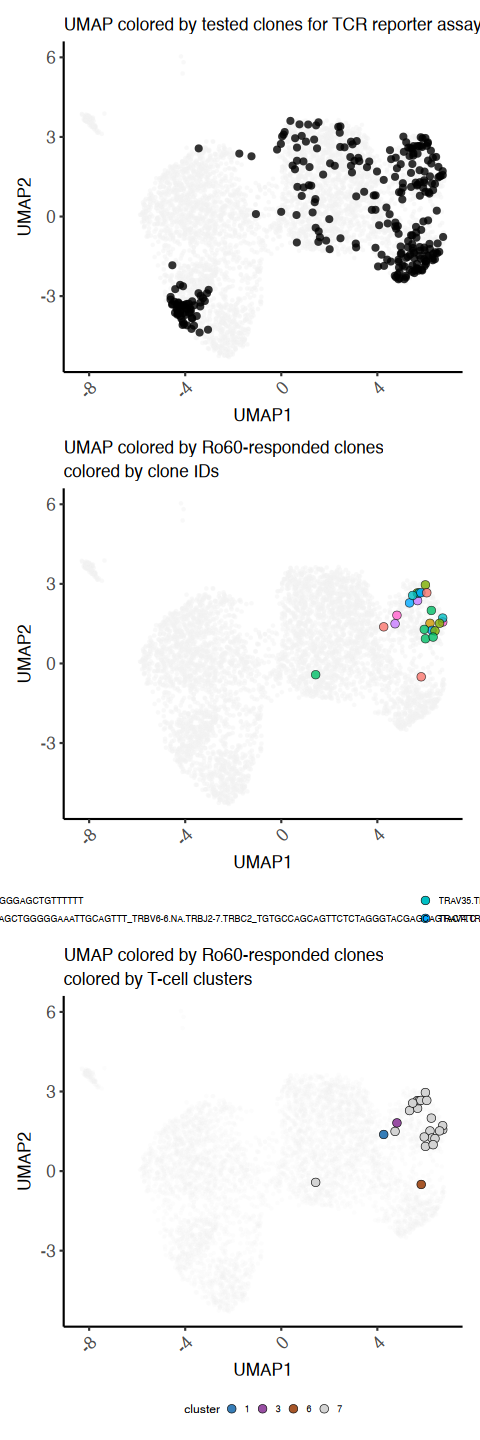

In [69]:
options(repr.plot.width = 4, repr.plot.height = 12)
ord = cbind(seurat_t[["umap"]]@cell.embeddings,
            seurat_t@meta.data) %>% 
  #merge(.,cluster_df[cluster_df$cell=="T",],by.x="seurat_clusters",by.y="cluster") %>%
  dplyr::mutate(cluster = Idents(seurat_t)) %>%
  #dplyr::filter(!grepl("CD8$",clu_name) & !grepl("DN$",clu_name) & !grepl("MT+",clu_name) & !grepl("replicating",clu_name)) %>% # CD4T-subclusters in T-cluster
  dplyr::filter(!is.na(highlight)) %>%
  .$cluster %>% unique() %>% as.character()
g2 = ggplot() +
  geom_point(
    data = cbind(seurat_t[["umap"]]@cell.embeddings,
                 seurat_t@meta.data) %>%
      #merge(.,cluster_df[cluster_df$cell=="T",],by.x="seurat_clusters",by.y="cluster") %>%
      dplyr::mutate(highlight = ifelse(!is.na(highlight),highlight,"hide")) %>%
      dplyr::mutate(cluster = seurat_t@meta.data$seurat_clusters) %>%
      dplyr::mutate(cluster = factor(ifelse(highlight=="hide",NA,cluster))) %>%
      dplyr::filter(highlight == "hide"),
    mapping = aes_string(x = "umap_1", y = "umap_2"),
    size = 1, stroke = 0.001, shape = 21, alpha = 0.2, color = "grey75", fill = "grey95"
  ) +
  geom_point(
    data = cbind(seurat_t[["umap"]]@cell.embeddings,
                 seurat_t@meta.data) %>% 
      dplyr::mutate(cluster = seurat_t@meta.data$seurat_clusters) %>%
      #merge(.,cluster_df[cluster_df$cell=="T",],by.x="seurat_clusters",by.y="cluster") %>%
      dplyr::filter(!is.na(highlight)),
    mapping = aes_string(x = "umap_1", y = "umap_2", fill = "cluster"),
    size = 2, stroke = 0.2, shape = 21, alpha = 1, color = "black",
  ) +
  labs(
    title = paste0("UMAP colored by Ro60-responded clones"),
    subtitle = "colored by T-cell clusters",
    x = "UMAP1",
    y = "UMAP2"
  ) + 
  scale_fill_manual(values = manual_colors,
                    name ="cluster"
                    #, labels = paste0("T-",cluster_df[cluster_df$cell=="T" & cluster_df$cluster %in% ord,]$cluster,":",cluster_df[cluster_df$cell=="T" & cluster_df$cluster %in% ord,]$clu_name)
                    ) +
  theme_classic(base_size = 10) +
  theme(strip.text.x=element_text(size=10, color="black", face="bold"),
        strip.text.y=element_text(size=10, color="black", face="bold"),
        legend.position = "bottom",
        plot.title = element_text(size=10),
        axis.title.x = element_text(size=10),
        axis.title.y = element_text(size =10),
        axis.text.y = element_text(size = 10),
        axis.text.x = element_text(size = 10, angle = 45, hjust=1),
        legend.text =  element_text(size = 5), 
        legend.key.size = grid::unit(0.4, "lines"),
        legend.title = element_text(size = 7, hjust = 0)) + 
  guides(colour = guide_legend(override.aes = list(alpha = 1, size = 2), ncol=1),
         fill = guide_legend(override.aes = list(alpha = 1, size = 2)),
         alpha = "none")
g = g0 / g1 / g2
ggsave(paste0(fig_dir,"/UMAP_Tcell_Ro60test_TCRreporter.pdf"), plot = g, width = 4, height = 12)